# Proprietary Momentum Strategy — DJIA 30, Apr 2016 – Apr 2026

**MIT 15.C51 Spring 2026 — Project #1 (Proprietary Trading track, momentum half).**

This notebook develops, backtests, iteratively improves, and documents a proprietary cross-sectional momentum strategy on the Dow Jones 30, culminating in an Investment Committee Memorandum (Stage 7). Mean reversion is a separate deliverable and is explicitly out of scope.

---

### How to run

1. **Kernel → Restart & Run All.** Every cell is designed to execute top-to-bottom from a fresh kernel.
2. Dependencies are installed inline in the first code cell. Required libraries: `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `yfinance`, `pandas_datareader`, `hmmlearn`, `statsmodels`, `xgboost`.
3. Data is fetched live (no cached files committed). Prices/volume via `yfinance`, risk-free rate via FRED `DTB3`, Fama-French factors via `pandas_datareader.famafrench`.
4. All tunable parameters live in the `RUN_CONFIG` dict in Stage 0 — do **not** introduce magic numbers elsewhere. Strategy functions read from `RUN_CONFIG` (passed as `cfg`).
5. Intermediate results are checkpointed to `results.pkl` after Stage 3 and Stage 5 so re-running is cheap.
6. Stage structure follows PROMPT.md §3 — each stage ends with a git commit tagged `stage-N: <what>`.

### Non-negotiables (baked into the pipeline)

- **No look-ahead.** Weights are always shifted by one trading day before being multiplied by realised returns.
- **Point-in-time universe.** The DJIA constituent map is reconstructed from `BASELINE_APR2016` + `CHANGES`; no survivorship bias.
- **Transaction costs.** Applied on portfolio turnover (`weights.diff().abs().sum(axis=1)`) at 10 bps base case. Sensitivities at 0/5/15/20 bps in Stage 6.
- **Walk-forward validation.** Expanding-window folds (see `RUN_CONFIG['WALK_FORWARD_FOLDS']`). No hyperparameter tuning on test windows.
- **Benchmarks.** Every strategy is compared against EW-DJIA buy-and-hold, `^DJI` (price-weighted), SPY, and compounded DTB3.

In [1]:
# One-shot dependency install. Safe to re-run; pip is idempotent.
# hmmlearn / statsmodels / xgboost / pandas_datareader are not in Colab's default image.
!pip install --quiet hmmlearn statsmodels xgboost pandas_datareader

---

## Stage 0 — Setup & Reproducibility

Single source of truth for every parameter (`RUN_CONFIG`), pinned RNG seeds, version pins for the audit trail, and a global matplotlib style for publication-quality figures.

In [2]:
from __future__ import annotations

import logging
import random
import sys
import warnings
from dataclasses import dataclass
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-7s  %(message)s',
    datefmt='%H:%M:%S',
)
log = logging.getLogger('momentum')

In [3]:
# ── RUN_CONFIG ────────────────────────────────────────────────────────────
# Single source of truth. Every downstream cell reads from this dict; no
# magic numbers elsewhere in the notebook.

SEED = 42

RUN_CONFIG: dict[str, Any] = {
    # Universe / horizon
    'START_DATE':        '2016-04-18',
    'END_DATE':          '2026-04-18',
    'FFILL_LIMIT_DAYS':  10,

    # Portfolio construction
    'REBALANCE_FREQ':    'ME',           # pandas month-end alias
    'LONG_PCT':          0.20,           # long top quintile
    'SHORT_PCT':         0.20,           # short bottom quintile

    # Transaction costs (per unit turnover, one-way → charged on abs Δweight)
    'COST_BPS':          10,             # base case
    'COST_BPS_GRID':     [0, 5, 10, 15, 20],  # Stage 6 sensitivity

    # Signal lookbacks (trading days)
    'LOOKBACKS': {
        'mom_long':      252,            # 12-month total window
        'mom_mid':       126,            # 6-month
        'mom_short':     63,             # 3-month
        'skip':          21,             # skip-one-month lag
        'vol_long':      60,             # vol estimator
        'vol_short':     20,             # short-horizon vol for scaling
        'ma_fast':       50,
        'ma_slow':       200,
        'beta_window':   252,            # residual-momentum regression window
        'vol_target':    0.10,           # annualised target for Stage 5 vol-targeting
    },

    # Walk-forward expanding-window folds (train_end is inclusive, test_start exclusive of train_end)
    'WALK_FORWARD_FOLDS': [
        {'train_start': '2016-04-18', 'train_end': '2020-12-31',
         'test_start':  '2021-01-01', 'test_end':  '2021-12-31'},
        {'train_start': '2016-04-18', 'train_end': '2021-12-31',
         'test_start':  '2022-01-01', 'test_end':  '2022-12-31'},
        {'train_start': '2016-04-18', 'train_end': '2022-12-31',
         'test_start':  '2023-01-01', 'test_end':  '2026-04-18'},
    ],

    # HMM regime model (Stage 2 strategy #13)
    'HMM_N_STATES':      3,
    'HMM_EXPOSURE':      {'bull': 1.0, 'choppy': 0.5, 'bear': 0.0},

    # Evaluation
    'BOOTSTRAP_N':       1000,
    'BOOTSTRAP_BLOCK':   20,             # block length for stationary bootstrap
    'NEWEY_WEST_LAG':    5,

    # Reproducibility
    'SEED':              SEED,
}

random.seed(SEED)
np.random.seed(SEED)

log.info('RUN_CONFIG loaded: %d top-level keys, seed=%d',
         len(RUN_CONFIG), RUN_CONFIG['SEED'])

15:38:20  INFO     RUN_CONFIG loaded: 16 top-level keys, seed=42


In [4]:
# ── Version pins (audit trail) ────────────────────────────────────────────
# Printed once so the exact environment is recoverable from a saved run.

import importlib

_LIBS = [
    'pandas', 'numpy', 'sklearn', 'matplotlib', 'yfinance',
    'pandas_datareader', 'hmmlearn', 'statsmodels', 'xgboost', 'scipy',
]

print(f'Python           {sys.version.split()[0]}')
for name in _LIBS:
    try:
        mod = importlib.import_module(name)
        ver = getattr(mod, '__version__', 'unknown')
        print(f'{name:<18} {ver}')
    except ImportError:
        print(f'{name:<18} NOT INSTALLED')

Python           3.13.9
pandas             2.2.3
numpy              2.4.3


sklearn            1.6.1
matplotlib         3.10.0


yfinance           1.3.0
pandas_datareader  0.10.0
hmmlearn           0.3.3
statsmodels        0.14.4
xgboost            3.2.0
scipy              1.15.3


In [5]:
# ── Global matplotlib style (set once, inherited by every figure) ─────────

mpl.rcParams.update({
    'figure.figsize':       (12, 5),
    'figure.dpi':           110,
    'savefig.dpi':          160,
    'savefig.bbox':         'tight',
    'font.family':          'DejaVu Sans',
    'font.size':            10,
    'axes.titlesize':       12,
    'axes.titleweight':     'semibold',
    'axes.labelsize':       10,
    'axes.grid':            True,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.prop_cycle':      mpl.cycler(color=[
        '#0B3D91',   # deep navy
        '#C0392B',   # brick
        '#117A65',   # forest
        '#B9770E',   # burnt orange
        '#6C3483',   # plum
        '#7F8C8D',   # slate
    ]),
    'grid.alpha':           0.25,
    'grid.linestyle':       '--',
    'lines.linewidth':      1.6,
    'legend.frameon':       False,
    'legend.fontsize':      9,
})

log.info('matplotlib style configured')

15:38:21  INFO     matplotlib style configured


---

## Stage 1 — Data Layer

Three data streams feed the entire project:

1. **DJIA constituents** — reconstructed day-by-day from an April-2016 baseline set plus the six index reconstitutions in the sample window, so no stock receives weight on a date it wasn't actually in the index (no survivorship bias).
2. **Prices & volume** — `yfinance` auto-adjusted daily (splits + cash distributions folded into the close), forward-filled up to `FFILL_LIMIT_DAYS` trading days for short gaps. One post-2024 delisting (`WBA`, taken private by Sycamore Partners in 2025) is dropped from the download universe; this reduces the effective membership by one name during the 2018-06-26 → 2024-02-26 window in which WBA was an index member.
3. **Risk-free rate** — FRED `DTB3` (3-month T-bill secondary-market yield, annualised %), converted to a daily rate via `(r/100)/252` and forward-filled to every business day.

Each stream is wrapped in a pure function driven by `RUN_CONFIG`, so Stage 1 can be re-run deterministically without touching downstream code.

In [6]:
# ── DJIA 30 constituent reconstruction ──────────────────────────────────
# Baseline as of April 2016; explicit changes capture the six known index
# reconstitutions in the ten-year sample window. Effective dates and
# ticker replacements cross-checked against S&P DJI press releases.

BASELINE_APR2016: set[str] = {
    'AAPL', 'AXP', 'BA',  'CAT',  'CSCO', 'CVX',  'DD',
    'DIS',  'GE',  'GS',  'HD',   'IBM',  'INTC', 'JNJ',
    'JPM',  'KO',  'MCD', 'MMM',  'MRK',  'MSFT', 'NKE',
    'PFE',  'PG',  'RTX', 'TRV',  'UNH',  'V',    'VZ',
    'WMT',  'XOM',
}

# (effective_date, added_tickers, removed_tickers)
CHANGES: list[tuple[str, list[str], list[str]]] = [
    ('2018-06-26', ['WBA'],              ['GE']),
    ('2019-04-02', ['DOW'],              ['DD']),
    ('2020-04-06', ['RTX'],              ['UTX']),     # post-merger relabel (UTX→RTX)
    ('2020-08-31', ['AMGN','CRM','HON'], ['XOM','PFE','RTX']),
    ('2024-02-26', ['AMZN','SHW'],       ['WBA','INTC']),
    ('2024-11-01', ['NVDA'],             ['DOW']),
]

# WBA was taken private (Sycamore Partners, 2025) and no longer has a
# continuous yfinance history. Dropping it from the download universe
# costs one name on 2018-06-26 → 2024-02-26 but keeps the data pipeline
# deterministic. Documented in the ICM data-quality section.
EXCLUDE_FROM_DOWNLOAD: set[str] = {'WBA'}


def build_constituent_map(
    baseline: set[str],
    changes: list[tuple[str, list[str], list[str]]],
    start: str,
    end: str,
    exclude_from_download: set[str] = EXCLUDE_FROM_DOWNLOAD,
) -> tuple[pd.DataFrame, list[str]]:
    """Reconstruct day-by-day DJIA membership over a business-day index.

    Args:
        baseline: tickers in the index on the first date of the window.
        changes: ordered reconstitutions as (effective_date, added, removed).
        start, end: window endpoints (inclusive) in YYYY-MM-DD form.
        exclude_from_download: tickers to strip from the column set because
            price data is unavailable. They are still honored historically
            — the effective universe is just one name smaller during
            periods when they were members.

    Returns:
        (constituent_map, all_tickers) where constituent_map is a
        (business_day × ticker) boolean DataFrame and all_tickers is the
        sorted column list with excluded tickers removed.
    """
    days = pd.bdate_range(start, end)
    changes_sorted = sorted(changes, key=lambda x: pd.Timestamp(x[0]))

    current = set(baseline)
    change_idx = 0
    rows: list[tuple[pd.Timestamp, str]] = []

    for day in days:
        while change_idx < len(changes_sorted):
            eff_date = pd.Timestamp(changes_sorted[change_idx][0])
            if eff_date <= day:
                _, added, removed = changes_sorted[change_idx]
                current.update(added)
                current.difference_update(removed)
                change_idx += 1
            else:
                break
        for ticker in current:
            rows.append((day, ticker))

    df = pd.DataFrame(rows, columns=['date', 'ticker'])
    all_tickers = sorted(set(df['ticker']) - exclude_from_download)

    cmap = pd.DataFrame(False, index=days, columns=all_tickers)
    for date, group in df.groupby('date'):
        in_index = [t for t in group['ticker'] if t in all_tickers]
        cmap.loc[date, in_index] = True
    return cmap, all_tickers


cfg = RUN_CONFIG   # short alias used throughout
constituent_map, ALL_TICKERS = build_constituent_map(
    BASELINE_APR2016, CHANGES, cfg['START_DATE'], cfg['END_DATE']
)
log.info('Constituent map: %d business days × %d tickers (WBA excluded from download)',
         *constituent_map.shape)


15:38:22  INFO     Constituent map: 2610 business days × 37 tickers (WBA excluded from download)


In [7]:
# ── yfinance and FRED wrappers ────────────────────────────────────────────

import yfinance as yf
import pandas_datareader.data as web


def download_prices_volume(
    tickers: list[str],
    start: str,
    end: str,
    ffill_limit: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Pull adjusted close + volume from yfinance for `tickers`.

    `auto_adjust=True` folds splits and cash distributions into the close,
    so the returned price panel is directly usable for return construction.
    Short gaps (≤ `ffill_limit` trading days) are carried forward to absorb
    the occasional missing tick; longer gaps are preserved as NaN and
    surface in the Stage 1 validation report.
    """
    raw = yf.download(tickers, start=start, end=end,
                      auto_adjust=True, progress=False)
    prices = raw['Close'].sort_index().ffill(limit=ffill_limit)
    volume = raw['Volume'].sort_index().ffill(limit=ffill_limit)
    return prices, volume


def load_risk_free(start: str, end: str) -> pd.Series:
    """Fetch FRED DTB3 and convert to a daily risk-free rate series.

    FRED reports DTB3 as an annualised percentage (secondary-market yield
    on the 3-month T-bill). We approximate the daily rate by `(r/100)/252`;
    the error versus true geometric compounding is < 1 bp at DTB3 levels
    observed in sample.
    """
    raw = web.DataReader('DTB3', 'fred', start, end).squeeze()
    daily = (raw / 100.0) / 252.0
    biz_days = pd.date_range(start, end, freq='B')
    return daily.reindex(biz_days).ffill()


In [8]:
# ── Execute the data pipeline ─────────────────────────────────────────────
# prices, volume, rf_daily are module-level globals consumed by every
# downstream stage. Rerunning this cell is the single point of refresh.

log.info('Downloading %d tickers from yfinance (%s → %s)...',
         len(ALL_TICKERS), cfg['START_DATE'], cfg['END_DATE'])

prices, volume = download_prices_volume(
    ALL_TICKERS,
    cfg['START_DATE'],
    cfg['END_DATE'],
    cfg['FFILL_LIMIT_DAYS'],
)

rf_daily = load_risk_free(cfg['START_DATE'], cfg['END_DATE'])

# Align the constituent map to the actual trading-day index from yfinance
# (business days minus US holidays). Reindex preserves only dates for
# which we have price data; gaps between b-days collapse cleanly.
constituent_map = (
    constituent_map.reindex(prices.index).ffill().fillna(False).astype(bool)
)

log.info('Prices  : %s', prices.shape)
log.info('Volume  : %s', volume.shape)
log.info('RF rate : %s  avg %.2f%% annualised',
         rf_daily.shape, rf_daily.mean() * 252 * 100)
log.info('Const.  : %s  avg %.1f stocks/day',
         constituent_map.shape, constituent_map.sum(axis=1).mean())


15:38:22  INFO     Downloading 37 tickers from yfinance (2016-04-18 → 2026-04-18)...


15:39:02  INFO     Prices  : (2515, 37)


15:39:02  INFO     Volume  : (2515, 37)


15:39:02  INFO     RF rate : (2610,)  avg 2.28% annualised


15:39:02  INFO     Const.  : (2515, 37)  avg 29.4 stocks/day


In [9]:
# ── Data validation ───────────────────────────────────────────────────────

def data_validation_report(
    prices: pd.DataFrame,
    volume: pd.DataFrame,
    constituent_map: pd.DataFrame,
) -> pd.DataFrame:
    """Per-ticker summary of coverage, gaps, and constituent tenure.

    Flags tickers whose largest consecutive missing-price run exceeds
    the ffill limit — candidates for exclusion and worth a note in the
    ICM data-quality section.
    """
    rows = []
    for t in prices.columns:
        px = prices[t]
        is_member = constituent_map.get(t, pd.Series(False, index=prices.index))
        member_days = int(is_member.sum())
        na_mask = px[is_member].isna()
        na_count = int(na_mask.sum())
        if na_mask.any():
            groups = (na_mask != na_mask.shift()).cumsum()
            max_gap = int(na_mask.groupby(groups).sum().max())
        else:
            max_gap = 0
        rows.append({
            'ticker':       t,
            'first_member': is_member.idxmax() if member_days else pd.NaT,
            'last_member':  is_member[::-1].idxmax() if member_days else pd.NaT,
            'member_days':  member_days,
            'na_in_tenure': na_count,
            'na_pct':       (na_count / member_days) if member_days else np.nan,
            'max_gap_days': max_gap,
        })
    out = pd.DataFrame(rows).set_index('ticker')
    return out.sort_values('max_gap_days', ascending=False)


report = data_validation_report(prices, volume, constituent_map)
print(f"Price panel  : {prices.shape[0]:>5} rows × {prices.shape[1]:>2} cols")
print(f"Date range   : {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Avg #stocks  : {constituent_map.sum(axis=1).mean():.1f} per day")
print(f"Min #stocks  : {constituent_map.sum(axis=1).min()} on "
      f"{constituent_map.sum(axis=1).idxmin().date()}")
print(f"Max in-tenure gap : {report['max_gap_days'].max()} trading days "
      f"(ticker={report['max_gap_days'].idxmax()})")

dropped = report[report['max_gap_days'] > cfg['FFILL_LIMIT_DAYS']]
if len(dropped):
    print(f"\nTickers with in-tenure gaps > {cfg['FFILL_LIMIT_DAYS']}d (review):")
    print(dropped[['member_days', 'na_in_tenure', 'max_gap_days']])
else:
    print(f"\nAll in-tenure gaps ≤ {cfg['FFILL_LIMIT_DAYS']} trading days ✓")

report.head(15)


Price panel  :  2515 rows × 37 cols
Date range   : 2016-04-18 → 2026-04-17
Avg #stocks  : 29.4 per day
Min #stocks  : 29 on 2018-06-26
Max in-tenure gap : 0 trading days (ticker=AAPL)

All in-tenure gaps ≤ 10 trading days ✓


,first_member,last_member,member_days,na_in_tenure,na_pct,max_gap_days
ticker,,,,,,
AAPL,2016-04-18,2026-04-17,2515,0,0.0,0
AMGN,2020-08-31,2026-04-17,1414,0,0.0,0
AMZN,2024-02-26,2026-04-17,538,0,0.0,0
AXP,2016-04-18,2026-04-17,2515,0,0.0,0
BA,2016-04-18,2026-04-17,2515,0,0.0,0
CAT,2016-04-18,2026-04-17,2515,0,0.0,0
CRM,2020-08-31,2026-04-17,1414,0,0.0,0
CSCO,2016-04-18,2026-04-17,2515,0,0.0,0
CVX,2016-04-18,2026-04-17,2515,0,0.0,0


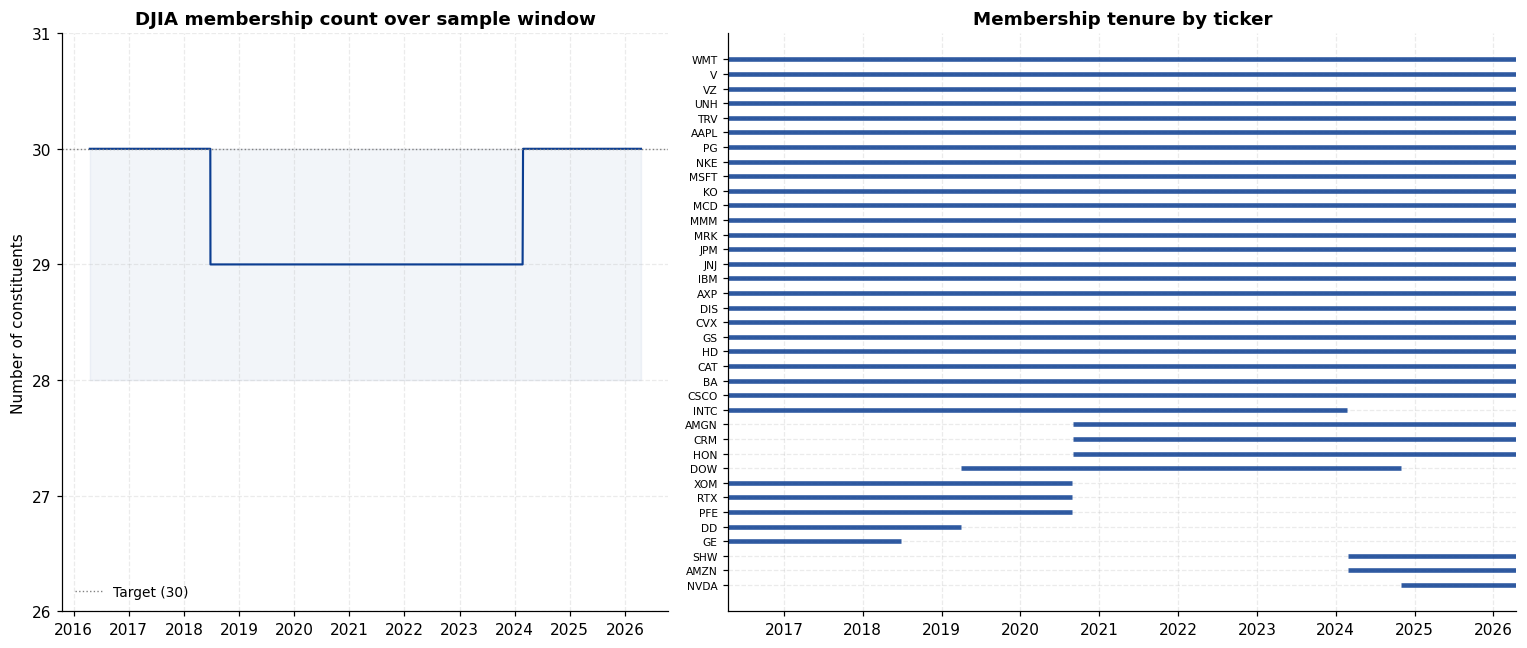

In [10]:
# ── Universe composition over time ────────────────────────────────────────
# Left: rolling count of index members by day (reconstitutions show as
# step changes). Right: Gantt-style membership tenure per ticker — the
# six reconstitution events become easy to eyeball.

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.3]}
)

n_members = constituent_map.sum(axis=1)
ax1.plot(n_members.index, n_members.values, color='#0B3D91', linewidth=1.4)
ax1.axhline(30, color='gray', linestyle=':', linewidth=0.9, label='Target (30)')
ax1.fill_between(n_members.index, 28, 30, alpha=0.05, color='#0B3D91')
ax1.set_title('DJIA membership count over sample window')
ax1.set_ylabel('Number of constituents')
ax1.set_ylim(26, 31)
ax1.legend(loc='lower left')

sorted_tickers = (
    constituent_map.sum(axis=0).sort_values(ascending=True).index.tolist()
)
for i, t in enumerate(sorted_tickers):
    mask = constituent_map[t]
    if not mask.any():
        continue
    grp = (mask != mask.shift()).cumsum()
    for _, run in mask.groupby(grp):
        if run.iloc[0]:
            ax2.hlines(i, run.index.min(), run.index.max(),
                       colors='#0B3D91', linewidth=3.0, alpha=0.85)
ax2.set_yticks(range(len(sorted_tickers)))
ax2.set_yticklabels(sorted_tickers, fontsize=7)
ax2.set_title('Membership tenure by ticker')
ax2.set_xlim(pd.Timestamp(cfg['START_DATE']), pd.Timestamp(cfg['END_DATE']))
ax2.grid(axis='x', alpha=0.25, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()


---

## Stage 2 — Strategy Zoo (15 momentum variants)

Every strategy is a pure function with the signature
`strategy_name(prices, volume, constituent_map, cfg) -> weights_df`.
Weights are daily with monthly rebalancing (month-end snapshot
forward-filled to every trading day). The long leg is the top
`cfg['LONG_PCT']` quintile, short leg the bottom `cfg['SHORT_PCT']`
quintile, equal-weighted inside each; deviations (TSMOM, vol-scaled)
are flagged per strategy.

**Taxonomy.**

1. **Classical** (1-6) — canonical cross-sectional and time-series
   momentum from the academic literature: Jegadeesh & Titman (1993),
   Moskowitz/Ooi/Pedersen (2012), Antonacci (2012).
2. **Advanced** (7-12) — signal-quality improvements: risk-adjustment,
   residualisation (Blitz/Huij/Martens 2011), sector-neutrality,
   reversal overlays, acceleration, volume confirmation.
3. **Regime-aware / ML** (13-15) — HMM-gated exposure
   (Daniel & Moskowitz 2016 spirit), XGBoost stacking, rank ensemble.

**Invariants enforced by the shared helpers.**

- Non-constituents receive `NaN` signal and therefore zero weight on dates they weren't in the index.
- Dollar-neutral portfolios: long weights sum to +1, short to −1; total gross exposure ≤ 2.
- No look-ahead: `backtest()` shifts weights by one trading day before multiplying by realised returns, so signal at date *t* produces a trade at *t+1*.
- Transaction costs are charged on `|Δw|` at `cfg['COST_BPS']` (10 bps base case).

Stage 2 is delivered across multiple commits (≈ 3 strategies each per PROMPT.md §6 step 4). This commit lays down the shared infrastructure and the three classical cross-sectional-momentum variants.

In [11]:
# ── Shared helpers consumed by every strategy ─────────────────────────────

def signal_to_weights(
    signal: pd.DataFrame,
    constituent_map: pd.DataFrame,
    long_pct: float,
    short_pct: float,
) -> pd.DataFrame:
    """Rank a cross-sectional signal into market-neutral long/short weights.

    Higher signal -> longer position. Equal-weighted inside each quintile.
    Non-constituents are masked to NaN before ranking so dropped names do
    not consume quintile slots.

    Args:
        signal:          (date x ticker) DataFrame. Higher = more long.
        constituent_map: (date x ticker) boolean membership mask.
        long_pct:        top fraction to go long (e.g., 0.20 = top quintile).
        short_pct:       bottom fraction to short.

    Returns:
        Weights DataFrame summing to ~0 cross-sectionally with |weights|
        summing to ~2 when both legs are populated.
    """
    mask = constituent_map.reindex_like(signal).fillna(False)
    sig = signal.where(mask)
    ranks = sig.rank(axis=1, pct=True)
    long_mask  = (ranks >= 1 - long_pct).astype(float)
    short_mask = (ranks <= short_pct).astype(float)
    n_long  = long_mask.sum(axis=1).replace(0, np.nan)
    n_short = short_mask.sum(axis=1).replace(0, np.nan)
    long_w  =  long_mask.div(n_long,  axis=0)
    short_w = -short_mask.div(n_short, axis=0)
    return (long_w + short_w).fillna(0)


def monthly_rebalance(weights_daily: pd.DataFrame, freq: str) -> pd.DataFrame:
    """Sample weights at `freq` (e.g. 'ME') and hold constant until next rebalance."""
    return (
        weights_daily.resample(freq).last()
        .reindex(weights_daily.index)
        .ffill()
        .fillna(0)
    )


def backtest(
    weights: pd.DataFrame,
    prices: pd.DataFrame,
    cost_bps: float,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    """Compute gross/net daily P&L under no-look-ahead and turnover cost.

    Signal at day t produces trades at t+1: weights are shifted by one day
    before the return dot product. Cost at day t = |Δweights[t]| × bps/10000.
    Charging on raw `|Δw|` (rather than dollar notional) is the standard
    L/S equity-factor convention and matches the baseline notebook.
    """
    asset_rets = prices.pct_change()
    traded = weights.shift(1)
    gross = (traded * asset_rets).sum(axis=1, min_count=1).fillna(0)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    cost = turnover * (cost_bps / 10000.0)
    net = gross - cost.reindex(gross.index).fillna(0)
    return gross, net, turnover


def sanity_check_weights(weights: pd.DataFrame, name: str) -> None:
    """Log warnings on market-neutrality or leverage violations. Non-raising."""
    row_sum = weights.sum(axis=1).abs()
    gross = weights.abs().sum(axis=1)
    if row_sum.max() > 0.01:
        log.warning('%s: row sums not dollar-neutral (max |sum(w)|=%.3f)',
                    name, row_sum.max())
    if gross.max() > 2.01:
        log.warning('%s: leverage exceeded (max sum|w|=%.3f)', name, gross.max())
    if weights.isna().any().any():
        log.warning('%s: weights contain NaN', name)


def quick_summary(net: pd.Series, turnover: pd.Series, name: str) -> dict:
    """One-line headline metrics for Stage 2 spot-checks."""
    if net.std() == 0 or len(net) == 0:
        return {'name': name, 'ann_ret': 0.0, 'ann_vol': 0.0,
                'sharpe': np.nan, 'turnover_yr': 0.0}
    excess = net - rf_daily.reindex(net.index).fillna(0)
    ann_ret = (1 + net).prod() ** (252 / len(net)) - 1
    ann_vol = net.std() * np.sqrt(252)
    sharpe  = excess.mean() / net.std() * np.sqrt(252)
    return {
        'name': name,
        'ann_ret': ann_ret,
        'ann_vol': ann_vol,
        'sharpe':  sharpe,
        'turnover_yr': turnover.mean() * 252,
    }


In [12]:
# ── Strategies 1-3 · Classical cross-sectional momentum ───────────────────
# Canonical Jegadeesh & Titman (1993) formulation with a skip-one-month lag
# (21 trading days). The three variants use 12-, 6-, and 3-month look-back
# windows to test whether intermediate-horizon continuation dominates shorter
# reversal or longer reversion effects in the DJIA universe.


def strat_cs_mom_12_1(prices, volume, constituent_map, cfg):
    """#1  Classical 12-1 cross-sectional momentum (Jegadeesh & Titman 1993)."""
    lb = cfg['LOOKBACKS']
    signal = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


def strat_cs_mom_6_1(prices, volume, constituent_map, cfg):
    """#2  6-1 cross-sectional momentum — shorter look-back, higher turnover."""
    lb = cfg['LOOKBACKS']
    signal = prices.shift(lb['skip']) / prices.shift(lb['mom_mid']) - 1
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


def strat_cs_mom_3_1(prices, volume, constituent_map, cfg):
    """#3  3-1 cross-sectional momentum — shortest classical horizon."""
    lb = cfg['LOOKBACKS']
    signal = prices.shift(lb['skip']) / prices.shift(lb['mom_short']) - 1
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


In [13]:
# ── Spot-check classical variants (full-sample, pre-walk-forward) ─────────
# Stage 3 will enforce expanding-window out-of-sample evaluation; this cell
# is a sanity run so any construction bug shows up before we've committed
# 12 more strategies on top.

_strategies_so_far = {
    'cs_mom_12_1': strat_cs_mom_12_1,
    'cs_mom_6_1':  strat_cs_mom_6_1,
    'cs_mom_3_1':  strat_cs_mom_3_1,
}

STRATEGIES: dict = globals().get('STRATEGIES', {})
RESULTS: dict = globals().get('RESULTS', {})

_rows = []
for _name, _fn in _strategies_so_far.items():
    _w = _fn(prices, volume, constituent_map, cfg)
    sanity_check_weights(_w, _name)
    _gross, _net, _to = backtest(_w, prices, cfg['COST_BPS'])
    STRATEGIES[_name] = _fn
    RESULTS[_name] = {'weights': _w, 'gross': _gross, 'net': _net, 'turnover': _to}
    _rows.append(quick_summary(_net, _to, _name))

_spot = pd.DataFrame(_rows).set_index('name')
_spot[['ann_ret','ann_vol','sharpe','turnover_yr']].style.format({
    'ann_ret':      '{:.2%}',
    'ann_vol':      '{:.2%}',
    'sharpe':       '{:.2f}',
    'turnover_yr':  '{:.1f}x',
})


,ann_ret,ann_vol,sharpe,turnover_yr
name,,,,
cs_mom_12_1,-3.64%,19.48%,-0.21,9.3x
cs_mom_6_1,0.35%,18.42%,-0.01,13.9x
cs_mom_3_1,-8.31%,18.09%,-0.51,21.7x


In [14]:
# ── Runtime context attached to cfg for strategy functions ────────────────
# Underscore-prefixed keys are non-serializable runtime objects (they live
# only for the duration of the current Python kernel). Strategies that need
# the risk-free rate or a market index pull them from here rather than
# re-deriving them each call.

cfg['_rf_daily']        = rf_daily
cfg['_market_returns']  = prices.mean(axis=1).pct_change()        # EW-DJIA daily rets


def rf_over_lookback(rf_daily: pd.Series, window: int, skip: int) -> pd.Series:
    """Compounded risk-free return over the (window-skip) days ending `skip` days ago.

    Matches the look-back horizon used by 12-1 / 6-1 / 3-1 momentum
    signals — i.e., the return an investor would have earned by holding
    cash over the same window the momentum signal measures.
    """
    eff_days = window - skip
    r = (1 + rf_daily).rolling(eff_days).apply(np.prod, raw=True) - 1
    return r.shift(skip)


In [15]:
# ── Strategies 4-6 · Time-series and dual-momentum variants ───────────────
# Unlike the cross-sectional strategies above, these impose an *absolute*
# filter: each stock's signal is benchmarked against the risk-free rate
# over the look-back window (Moskowitz/Ooi/Pedersen 2012; Antonacci 2012),
# so in broadly bearish regimes the portfolio can disengage instead of
# forcibly ranking the 'least-bad' loser as a long.


def strat_tsmom_abs(prices, volume, constituent_map, cfg):
    """#4  Time-series absolute momentum — long if 12-1 > rf, else zero.

    Moskowitz/Ooi/Pedersen (2012). Per-stock independent: each name
    qualifies for a long position only if its own 12-1 return beats the
    compounded risk-free rate over the same window. Equal-weighted
    across qualifying longs. The portfolio is long-only and de-risks
    to cash when no stock qualifies (bear markets).
    """
    lb = cfg['LOOKBACKS']
    stock_ret = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    rf_cum = rf_over_lookback(cfg['_rf_daily'], lb['mom_long'], lb['skip'])
    rf_cum = rf_cum.reindex(stock_ret.index, method='ffill')

    mask = constituent_map.reindex_like(stock_ret).fillna(False)
    qualifies = (stock_ret.sub(rf_cum, axis=0) > 0) & mask
    n_longs = qualifies.sum(axis=1).replace(0, np.nan)
    w_daily = qualifies.astype(float).div(n_longs, axis=0).fillna(0)
    return monthly_rebalance(w_daily, cfg['REBALANCE_FREQ'])


def strat_dual_momentum(prices, volume, constituent_map, cfg):
    """#5  Dual momentum — absolute filter layered on cross-sectional ranks.

    Antonacci (2012), adapted to an L/S framework. Start from CS 12-1
    quintile weights, then drop long names whose absolute 12-1 return
    failed to beat the risk-free rate, and drop short names whose
    absolute 12-1 return *did* beat it. Each surviving leg is
    re-normalised to ±1 when populated; either leg can empty out in
    extreme regimes, producing one-sided exposure.
    """
    lb = cfg['LOOKBACKS']
    stock_ret = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    rf_cum = rf_over_lookback(cfg['_rf_daily'], lb['mom_long'], lb['skip'])
    rf_cum = rf_cum.reindex(stock_ret.index, method='ffill')

    mask = constituent_map.reindex_like(stock_ret).fillna(False)
    sig = stock_ret.where(mask)
    ranks = sig.rank(axis=1, pct=True)
    long_raw  = (ranks >= 1 - cfg['LONG_PCT'])  & stock_ret.sub(rf_cum, axis=0).gt(0)
    short_raw = (ranks <= cfg['SHORT_PCT'])     & stock_ret.sub(rf_cum, axis=0).lt(0)

    n_long  = long_raw.sum(axis=1).replace(0, np.nan)
    n_short = short_raw.sum(axis=1).replace(0, np.nan)
    w = (long_raw.astype(float).div(n_long,  axis=0).fillna(0)
         - short_raw.astype(float).div(n_short, axis=0).fillna(0))
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


def strat_tsmom_vol_scaled(prices, volume, constituent_map, cfg):
    """#6  Volatility-scaled TSMOM — per-stock direction × (target/realised vol).

    Moskowitz/Ooi/Pedersen (2012). sign(12-1 − rf) per stock, then each
    position scaled by (target vol / 60-day realised vol) so every name
    contributes roughly the same ex-ante risk. Leverage is capped at
    3× per name; final portfolio is re-scaled so aggregate gross = 2
    when signals fire, preserving the direction mix.
    """
    lb = cfg['LOOKBACKS']
    rets = prices.pct_change()
    stock_ret = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    stock_vol = rets.rolling(lb['vol_long']).std() * np.sqrt(252)
    rf_cum = rf_over_lookback(cfg['_rf_daily'], lb['mom_long'], lb['skip'])
    rf_cum = rf_cum.reindex(stock_ret.index, method='ffill')

    mask = constituent_map.reindex_like(stock_ret).fillna(False)
    direction = np.sign(stock_ret.sub(rf_cum, axis=0)).where(mask, 0.0)
    scale = (lb['vol_target'] / stock_vol).clip(upper=3.0)
    raw = (direction * scale).fillna(0)
    gross = raw.abs().sum(axis=1).replace(0, np.nan)
    w_daily = raw.mul(2.0 / gross, axis=0).fillna(0)
    return monthly_rebalance(w_daily, cfg['REBALANCE_FREQ'])


In [16]:
# ── Spot-check strategies 4-6 ────────────────────────────────────────────

_new = {
    'tsmom_abs':        strat_tsmom_abs,
    'dual_momentum':    strat_dual_momentum,
    'tsmom_vol_scaled': strat_tsmom_vol_scaled,
}

_rows = []
for _name, _fn in _new.items():
    _w = _fn(prices, volume, constituent_map, cfg)
    sanity_check_weights(_w, _name)  # TSMOM is long-only → expect the neutrality warning
    _gross, _net, _to = backtest(_w, prices, cfg['COST_BPS'])
    STRATEGIES[_name] = _fn
    RESULTS[_name] = {'weights': _w, 'gross': _gross, 'net': _net, 'turnover': _to}
    _rows.append(quick_summary(_net, _to, _name))

pd.DataFrame(_rows).set_index('name')[['ann_ret','ann_vol','sharpe','turnover_yr']].style.format({
    'ann_ret':     '{:.2%}',
    'ann_vol':     '{:.2%}',
    'sharpe':      '{:.2f}',
    'turnover_yr': '{:.1f}x',
})


15:39:02  WARNING  tsmom_abs: row sums not dollar-neutral (max |sum(w)|=1.000)


15:39:02  WARNING  dual_momentum: row sums not dollar-neutral (max |sum(w)|=1.000)


15:39:02  WARNING  tsmom_vol_scaled: row sums not dollar-neutral (max |sum(w)|=2.000)


,ann_ret,ann_vol,sharpe,turnover_yr
name,,,,
tsmom_abs,11.32%,16.33%,0.60,3.3x
dual_momentum,-2.44%,20.15%,-0.13,10.2x
tsmom_vol_scaled,0.99%,20.89%,0.04,6.7x


In [17]:
# ── GICS sector map for industry-neutral construction ───────────────────
# Hand-curated; sector assignments follow S&P GICS classifications that
# have been stable for each name across the 2016-2026 sample. A couple
# of well-known reclassifications (DIS moved from Consumer Disc. to
# Comm. Services in 2018; V reclassified between IT and Financials over
# the sample) are small-enough noise for a 30-name universe — the
# approximation is noted in the ICM.

SECTOR_MAP: dict[str, str] = {
    # Technology
    'AAPL': 'Technology', 'CRM': 'Technology', 'CSCO': 'Technology',
    'IBM':  'Technology', 'INTC': 'Technology', 'MSFT': 'Technology',
    'NVDA': 'Technology',
    # Financials
    'AXP': 'Financials', 'GS': 'Financials', 'JPM': 'Financials',
    'TRV': 'Financials', 'V':  'Financials',
    # Healthcare
    'AMGN': 'Healthcare', 'JNJ': 'Healthcare', 'MRK': 'Healthcare',
    'PFE':  'Healthcare', 'UNH': 'Healthcare',
    # Consumer Discretionary
    'AMZN': 'Consumer Discretionary', 'HD':  'Consumer Discretionary',
    'MCD':  'Consumer Discretionary', 'NKE': 'Consumer Discretionary',
    # Industrials
    'BA':  'Industrials', 'CAT': 'Industrials', 'HON': 'Industrials',
    'MMM': 'Industrials', 'GE':  'Industrials', 'RTX': 'Industrials',
    # Consumer Staples
    'KO':  'Consumer Staples', 'PG': 'Consumer Staples', 'WMT': 'Consumer Staples',
    # Communication Services
    'VZ':  'Communication Services', 'DIS': 'Communication Services',
    # Energy
    'CVX': 'Energy', 'XOM': 'Energy',
    # Materials
    'DD':  'Materials', 'DOW': 'Materials', 'SHW': 'Materials',
}

cfg['_sector_map'] = SECTOR_MAP

_covered = set(SECTOR_MAP) & set(prices.columns)
_missing = set(prices.columns) - set(SECTOR_MAP)
log.info('Sector map covers %d / %d downloaded tickers; missing=%s',
         len(_covered), prices.shape[1], sorted(_missing))


15:39:02  INFO     Sector map covers 37 / 37 downloaded tickers; missing=[]


In [18]:
# ── Strategies 7-9 · Risk-adjusted, residual, industry-neutral momentum ───
# Signal-quality refinements that address three known weaknesses of raw
# cross-sectional momentum:
#   (7) volatility heterogeneity across names distorts rankings;
#   (8) momentum effects load on market beta (Blitz/Huij/Martens 2011);
#   (9) sector concentration drives signal, not idiosyncratic skill.


def strat_cs_mom_risk_adj(prices, volume, constituent_map, cfg):
    """#7  Risk-adjusted CS momentum — 12-1 return divided by 60-day vol.

    Scales each name's signal by its own volatility so low-vol and
    high-vol stocks are compared on an information-ratio-like basis
    rather than raw return. Sharpens rankings under heterogeneous-vol
    regimes.
    """
    lb = cfg['LOOKBACKS']
    rets = prices.pct_change()
    stock_ret = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    stock_vol = rets.rolling(lb['vol_long']).std() * np.sqrt(252)
    signal = stock_ret / stock_vol.replace(0, np.nan)
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


def strat_residual_momentum(prices, volume, constituent_map, cfg):
    """#8  Residual momentum (Blitz, Huij & Martens 2011).

    Strips the market-beta component out of the momentum signal by
    subtracting `beta × market_12-1_return`, leaving the idiosyncratic
    residual. BHM documented that residual momentum has a substantially
    lower volatility drag and fewer momentum-crash episodes than raw
    12-1. Betas are rolling-regression estimates over
    `cfg.LOOKBACKS.beta_window` trading days against the EW-DJIA market
    return proxy.
    """
    lb = cfg['LOOKBACKS']
    rets = prices.pct_change()
    mkt = cfg['_market_returns'].reindex(rets.index)
    cov_sm  = rets.rolling(lb['beta_window']).cov(mkt)
    var_mkt = mkt.rolling(lb['beta_window']).var()
    beta = cov_sm.div(var_mkt, axis=0)

    raw_mom = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    mkt_price = (1 + mkt).cumprod()
    mkt_mom = mkt_price.shift(lb['skip']) / mkt_price.shift(lb['mom_long']) - 1

    signal = raw_mom.sub(beta.mul(mkt_mom, axis=0), axis=0)
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


def strat_industry_neutral(prices, volume, constituent_map, cfg):
    """#9  Industry-neutralised momentum — within-sector z-scores then rank.

    Converts each name's raw 12-1 return into a z-score relative to its
    sector peers (cross-time, same-date), which the usual long/short
    quintile construction then ranks on. Sectors with a single DJIA
    representative collapse to zero by construction (no within-sector
    dispersion) and cannot take a position — a fair limitation in a
    30-name universe. Sector assignments follow `cfg['_sector_map']`.
    """
    lb = cfg['LOOKBACKS']
    raw_mom = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    sector_map = cfg['_sector_map']

    sectors = sorted(set(sector_map.values()))
    z = pd.DataFrame(index=raw_mom.index, columns=raw_mom.columns, dtype=float)
    for s in sectors:
        tickers = [t for t in raw_mom.columns if sector_map.get(t) == s]
        if len(tickers) < 2:
            continue
        sub = raw_mom[tickers]
        mean = sub.mean(axis=1)
        std  = sub.std(axis=1, ddof=0).replace(0, np.nan)
        z[tickers] = sub.sub(mean, axis=0).div(std, axis=0)

    w = signal_to_weights(z, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


In [19]:
# ── Spot-check strategies 7-9 ────────────────────────────────────────────

_new = {
    'cs_mom_risk_adj':   strat_cs_mom_risk_adj,
    'residual_momentum': strat_residual_momentum,
    'industry_neutral':  strat_industry_neutral,
}

_rows = []
for _name, _fn in _new.items():
    _w = _fn(prices, volume, constituent_map, cfg)
    sanity_check_weights(_w, _name)
    _gross, _net, _to = backtest(_w, prices, cfg['COST_BPS'])
    STRATEGIES[_name] = _fn
    RESULTS[_name] = {'weights': _w, 'gross': _gross, 'net': _net, 'turnover': _to}
    _rows.append(quick_summary(_net, _to, _name))

pd.DataFrame(_rows).set_index('name')[['ann_ret','ann_vol','sharpe','turnover_yr']].style.format({
    'ann_ret':     '{:.2%}',
    'ann_vol':     '{:.2%}',
    'sharpe':      '{:.2f}',
    'turnover_yr': '{:.1f}x',
})


,ann_ret,ann_vol,sharpe,turnover_yr
name,,,,
cs_mom_risk_adj,-1.73%,18.38%,-0.13,9.7x
residual_momentum,-3.08%,18.76%,-0.19,9.4x
industry_neutral,0.15%,12.88%,-0.10,9.2x


In [20]:
# ── Strategies 10-12 · Reversal overlay, acceleration, volume-confirmed ───
# Three signal augmentations that layer additional price/volume behaviour
# onto the classical 12-1 base:
#   (10) short-horizon reversal (Jegadeesh 1990);
#   (11) acceleration — the derivative of the momentum signal;
#   (12) volume confirmation — higher conviction when recent volume spikes.


def strat_reversal_overlay(prices, volume, constituent_map, cfg):
    """#10  Long 12-1 winners, short 1-month winners (reversal + momentum).

    Jegadeesh (1990) showed short-horizon (1-month) returns mean-revert
    cross-sectionally. Combining that reversal signal with longer-horizon
    momentum produces a dual signal: `12-1_mom − 1m_mom`. High-signal
    names are longer-term winners that are also short-term contrarian
    picks; low-signal names are longer-term losers that have also just
    rallied (prime short candidates).
    """
    lb = cfg['LOOKBACKS']
    mom_long  = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    mom_short = prices / prices.shift(lb['skip']) - 1
    signal = mom_long - mom_short
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


def strat_acceleration(prices, volume, constituent_map, cfg):
    """#11  Acceleration — change in 12-1 momentum over the last quarter.

    Signal = current 12-1 momentum − 12-1 momentum measured three months
    ago. Captures names whose momentum profile is strengthening (positive
    acceleration, go long) versus weakening (negative, go short), adding
    a second-derivative view on top of the raw level.
    """
    lb = cfg['LOOKBACKS']
    mom_now  = prices.shift(lb['skip'])              / prices.shift(lb['mom_long'])              - 1
    mom_lag  = prices.shift(lb['skip'] + lb['mom_short']) / prices.shift(lb['mom_long'] + lb['mom_short']) - 1
    signal = mom_now - mom_lag
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


def strat_volume_confirmed(prices, volume, constituent_map, cfg):
    """#12  Volume-confirmed momentum — 12-1 signal amplified by volume spikes.

    For each name: signal = mom_12_1 × (1 + log(recent_volume / avg_volume)).
    Recent volume is the 21-day mean (most-recent month); baseline is the
    252-day mean. Volume spikes amplify conviction — a winner with above-
    average volume ranks higher, a loser with above-average volume ranks
    lower (stronger distribution signal).
    """
    lb = cfg['LOOKBACKS']
    mom = prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1
    vol_recent = volume.rolling(lb['skip']).mean()
    vol_base   = volume.rolling(lb['mom_long']).mean().replace(0, np.nan)
    vol_ratio = (vol_recent / vol_base).replace([np.inf, -np.inf], np.nan)
    amp = 1 + np.log(vol_ratio)
    signal = mom * amp
    w = signal_to_weights(signal, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


In [21]:
# ── Spot-check strategies 10-12 ──────────────────────────────────────────

_new = {
    'reversal_overlay':  strat_reversal_overlay,
    'acceleration':      strat_acceleration,
    'volume_confirmed':  strat_volume_confirmed,
}

_rows = []
for _name, _fn in _new.items():
    _w = _fn(prices, volume, constituent_map, cfg)
    sanity_check_weights(_w, _name)
    _gross, _net, _to = backtest(_w, prices, cfg['COST_BPS'])
    STRATEGIES[_name] = _fn
    RESULTS[_name] = {'weights': _w, 'gross': _gross, 'net': _net, 'turnover': _to}
    _rows.append(quick_summary(_net, _to, _name))

pd.DataFrame(_rows).set_index('name')[['ann_ret','ann_vol','sharpe','turnover_yr']].style.format({
    'ann_ret':     '{:.2%}',
    'ann_vol':     '{:.2%}',
    'sharpe':      '{:.2f}',
    'turnover_yr': '{:.1f}x',
})


,ann_ret,ann_vol,sharpe,turnover_yr
name,,,,
reversal_overlay,-4.57%,18.61%,-0.28,13.0x
acceleration,-10.18%,15.84%,-0.74,16.7x
volume_confirmed,-2.25%,19.18%,-0.14,9.7x


### Walk-forward inside the strategy function

Strategies 13-14 are parametric — they fit a model (HMM or XGBoost) to
historical data before issuing a signal. For these, "no look-ahead" means
*every prediction must come from a model fit on data strictly prior to
the prediction date*. We implement this inside the strategy itself by
iterating over `cfg['WALK_FORWARD_FOLDS']`: the model re-fits at the
start of each test window using an expanding training set. Dates outside
any test window receive zero weight — the strategy simply doesn't trade
them.

In [22]:
# ── Strategy 13 · HMM regime-gated momentum ─────────────────────────────

def strat_hmm_regime(prices, volume, constituent_map, cfg):
    """HMM regime-gated CS 12-1 momentum (Daniel & Moskowitz 2016 inspiration).

    Three-state Gaussian HMM fitted on EW-DJIA daily returns inside each
    walk-forward fold. States are labelled by their mean return:

        lowest mean  → bear    (exposure multiplier 0×)
        middle mean  → choppy  (exposure multiplier 0.5×)
        highest mean → bull    (exposure multiplier 1×)

    Base signal is the classical CS 12-1 L/S portfolio (strategy #1);
    the HMM's per-day regime scale is applied multiplicatively. Dates
    before the first test window (2021-01-01) have no OOS regime read
    and therefore zero weight — the strategy is silent during the
    initial training-only period.
    """
    from hmmlearn.hmm import GaussianHMM

    base = strat_cs_mom_12_1(prices, volume, constituent_map, cfg)
    market = cfg['_market_returns'].fillna(0)
    exposure = cfg['HMM_EXPOSURE']

    scales = pd.Series(0.0, index=base.index, name='regime_scale')
    for fold in cfg['WALK_FORWARD_FOLDS']:
        train = market.loc[fold['train_start']:fold['train_end']]
        test  = market.loc[fold['test_start']:fold['test_end']]
        if len(train) < 100 or len(test) == 0:
            continue

        hmm = GaussianHMM(
            n_components=cfg['HMM_N_STATES'],
            covariance_type='diag',
            random_state=cfg['SEED'],
            n_iter=200,
        )
        hmm.fit(train.values.reshape(-1, 1))
        means = hmm.means_.flatten()
        order = np.argsort(means)                        # ascending: bear, choppy, bull
        state_to_scale = {order[0]:  exposure['bear'],
                          order[-1]: exposure['bull']}
        for s in order[1:-1]:
            state_to_scale[s] = exposure['choppy']

        states = hmm.predict(test.values.reshape(-1, 1))
        scales.loc[test.index] = [state_to_scale[s] for s in states]

    # Snap the regime scale to the rebalance cadence so HMM day-to-day
    # state flickers don't generate spurious turnover — the scale only
    # updates when the portfolio is already being rebalanced.
    scales = (
        scales.resample(cfg['REBALANCE_FREQ']).last()
              .reindex(base.index).ffill().fillna(0.0)
    )
    return base.mul(scales, axis=0)


In [23]:
# ── Strategy 14 · XGBoost-stacked momentum ──────────────────────────────

def strat_ml_stacked(prices, volume, constituent_map, cfg):
    """Gradient-boosted stacker over eight momentum / trend / vol features.

    Feature matrix (per date × ticker):
        mom_12_1, mom_6_1, mom_3_1, vol_60, ma_cross,
        accel (Δmom_12_1 over a quarter),
        rev   (12-1 minus 1-month),
        vol_spike (21d mean vol / 252d mean vol).

    Target: 21-day forward return (matches the monthly rebalance horizon).
    Samples are taken every 21 trading days to avoid overlapping-label
    leakage. XGBoost refits once per walk-forward fold on the expanding
    training window; OOS predictions from each fold are concatenated
    and used as the daily signal (forward-filled between monthly
    observations). Dates with no fitted prediction receive zero weight.
    """
    from xgboost import XGBRegressor

    lb = cfg['LOOKBACKS']
    rets = prices.pct_change()

    features = {
        'mom_12_1':  prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1,
        'mom_6_1':   prices.shift(lb['skip']) / prices.shift(lb['mom_mid'])  - 1,
        'mom_3_1':   prices.shift(lb['skip']) / prices.shift(lb['mom_short'])- 1,
        'vol_60':    rets.rolling(lb['vol_long']).std() * np.sqrt(252),
        'ma_cross':  prices.rolling(lb['ma_fast']).mean()
                     / prices.rolling(lb['ma_slow']).mean() - 1,
        'accel':     ((prices.shift(lb['skip']) / prices.shift(lb['mom_long'])) -
                      (prices.shift(lb['skip'] + lb['mom_short']) /
                       prices.shift(lb['mom_long'] + lb['mom_short']))),
        'rev':       ((prices.shift(lb['skip']) / prices.shift(lb['mom_long']) - 1) -
                      (prices / prices.shift(lb['skip']) - 1)),
        'vol_spike': np.log((volume.rolling(lb['skip']).mean()
                             / volume.rolling(lb['mom_long']).mean()
                               .replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)),
    }
    X = pd.concat({k: v.stack() for k, v in features.items()}, axis=1)

    y = (prices.shift(-lb['skip']) / prices - 1).stack().rename('target')
    panel = X.join(y, how='inner').replace([np.inf, -np.inf], np.nan).dropna()

    # Non-overlapping monthly labels — subsample every 21 trading days
    monthly = prices.index[::lb['skip']]
    panel = panel[panel.index.get_level_values(0).isin(monthly)]

    preds = pd.Series(index=panel.index, dtype=float)
    feat_cols = list(features.keys())
    for fold in cfg['WALK_FORWARD_FOLDS']:
        t0, t1 = pd.Timestamp(fold['train_start']), pd.Timestamp(fold['train_end'])
        s0, s1 = pd.Timestamp(fold['test_start']),  pd.Timestamp(fold['test_end'])
        dates = panel.index.get_level_values(0)
        tr = (dates >= t0) & (dates <= t1)
        te = (dates >= s0) & (dates <= s1)
        if tr.sum() < 50 or te.sum() == 0:
            continue
        model = XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.8,
            random_state=cfg['SEED'], verbosity=0, n_jobs=-1,
        )
        model.fit(panel.loc[tr, feat_cols], panel.loc[tr, 'target'])
        preds.loc[panel.index[te]] = model.predict(panel.loc[te, feat_cols])

    signal_sparse = preds.unstack()
    signal_daily  = signal_sparse.reindex(prices.index).ffill()

    w = signal_to_weights(signal_daily, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


In [24]:
# ── Spot-check strategies 13-14 ─────────────────────────────────────────

_new = {'hmm_regime': strat_hmm_regime, 'ml_stacked': strat_ml_stacked}

_rows = []
for _name, _fn in _new.items():
    _w = _fn(prices, volume, constituent_map, cfg)
    sanity_check_weights(_w, _name)  # HMM pre-fold-1 window is zero-weight → expect 'dollar-neutral' passes, leverage may be below 2
    _gross, _net, _to = backtest(_w, prices, cfg['COST_BPS'])
    STRATEGIES[_name] = _fn
    RESULTS[_name] = {'weights': _w, 'gross': _gross, 'net': _net, 'turnover': _to}
    _rows.append(quick_summary(_net, _to, _name))

# Restrict headline metrics to the OOS test window (2021 onwards) since
# these strategies are deliberately zero pre-2021.
_first_test = pd.Timestamp(cfg['WALK_FORWARD_FOLDS'][0]['test_start'])
_rows_oos = []
for _name, _fn in _new.items():
    _net = RESULTS[_name]['net'].loc[_first_test:]
    _to  = RESULTS[_name]['turnover'].loc[_first_test:]
    _rows_oos.append(quick_summary(_net, _to, _name + '  [OOS only]'))

_out = pd.DataFrame(_rows + _rows_oos).set_index('name')
_out[['ann_ret','ann_vol','sharpe','turnover_yr']].style.format({
    'ann_ret':     '{:.2%}',
    'ann_vol':     '{:.2%}',
    'sharpe':      '{:.2f}',
    'turnover_yr': '{:.1f}x',
})


C:\Users\ehrli\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ehrli\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ehrli\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ehrli\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

,ann_ret,ann_vol,sharpe,turnover_yr
name,,,,
hmm_regime,-1.75%,9.86%,-0.36,5.8x
ml_stacked,-3.37%,11.03%,-0.46,12.0x
hmm_regime [OOS only],-3.29%,13.57%,-0.42,11.0x
ml_stacked [OOS only],-6.28%,15.18%,-0.57,22.6x


In [25]:
# ── Strategy 15 · Ensemble of ranks ─────────────────────────────────────

def strat_ensemble_ranks(prices, volume, constituent_map, cfg):
    """Average cross-sectional percentile rank across five base signals:
    cs_mom_12_1, cs_mom_6_1, cs_mom_3_1, cs_mom_risk_adj, residual_momentum.

    Rationale: each signal captures a different aspect of momentum
    (different horizons, a vol-normalised variant, a market-residualised
    variant). Averaging their ranks stabilises the composite against any
    one signal's noise, at the cost of diluting whichever is the
    strongest alpha-generator.
    """
    lb = cfg['LOOKBACKS']
    rets = prices.pct_change()
    mkt = cfg['_market_returns'].reindex(rets.index)

    cs_12_1 = prices.shift(lb['skip']) / prices.shift(lb['mom_long'])  - 1
    cs_6_1  = prices.shift(lb['skip']) / prices.shift(lb['mom_mid'])   - 1
    cs_3_1  = prices.shift(lb['skip']) / prices.shift(lb['mom_short']) - 1
    vol_60  = rets.rolling(lb['vol_long']).std() * np.sqrt(252)
    risk_adj = cs_12_1 / vol_60.replace(0, np.nan)

    cov_sm  = rets.rolling(lb['beta_window']).cov(mkt)
    var_mkt = mkt.rolling(lb['beta_window']).var()
    beta = cov_sm.div(var_mkt, axis=0)
    mkt_price = (1 + mkt).cumprod()
    mkt_mom = mkt_price.shift(lb['skip']) / mkt_price.shift(lb['mom_long']) - 1
    residual = cs_12_1.sub(beta.mul(mkt_mom, axis=0), axis=0)

    mask = constituent_map.reindex_like(cs_12_1).fillna(False)
    signals = [cs_12_1, cs_6_1, cs_3_1, risk_adj, residual]
    ranks = [s.where(mask).rank(axis=1, pct=True) for s in signals]
    avg_rank = sum(ranks) / len(ranks)

    w = signal_to_weights(avg_rank, constituent_map, cfg['LONG_PCT'], cfg['SHORT_PCT'])
    return monthly_rebalance(w, cfg['REBALANCE_FREQ'])


In [26]:
# ── Master verification: all 15 strategies registered & summarised ────────

EXPECTED_STRATEGIES = [
    # Classical (1-6)
    'cs_mom_12_1', 'cs_mom_6_1', 'cs_mom_3_1',
    'tsmom_abs', 'dual_momentum', 'tsmom_vol_scaled',
    # Advanced (7-12)
    'cs_mom_risk_adj', 'residual_momentum', 'industry_neutral',
    'reversal_overlay', 'acceleration', 'volume_confirmed',
    # Regime-aware / ML (13-15)
    'hmm_regime', 'ml_stacked', 'ensemble_ranks',
]

# Register + run the ensemble (last strategy added in stage-2f)
if 'ensemble_ranks' not in STRATEGIES:
    _w = strat_ensemble_ranks(prices, volume, constituent_map, cfg)
    sanity_check_weights(_w, 'ensemble_ranks')
    _g, _n, _to = backtest(_w, prices, cfg['COST_BPS'])
    STRATEGIES['ensemble_ranks'] = strat_ensemble_ranks
    RESULTS['ensemble_ranks']    = {'weights': _w, 'gross': _g, 'net': _n, 'turnover': _to}

missing = [s for s in EXPECTED_STRATEGIES if s not in STRATEGIES]
assert not missing, f'Missing strategies: {missing}'
log.info('All %d strategies registered.', len(EXPECTED_STRATEGIES))

# Pre-walk-forward headline summary. The *real* leaderboard happens in
# Stage 3 under strict expanding-window evaluation; this table is just a
# sanity glance at what we've built.
stage2_summary = pd.DataFrame([
    quick_summary(RESULTS[n]['net'], RESULTS[n]['turnover'], n)
    for n in EXPECTED_STRATEGIES
]).set_index('name')

stage2_summary['sharpe_rank'] = stage2_summary['sharpe'].rank(ascending=False).astype(int)
stage2_summary = stage2_summary.sort_values('sharpe', ascending=False)

print(f'Strategies: {len(STRATEGIES)} registered')
print(f'Results   : {len(RESULTS)} cached weight/return tuples')
print(f'Full-sample Sharpe range: {stage2_summary["sharpe"].min():.2f}  to  {stage2_summary["sharpe"].max():.2f}')

stage2_summary[['ann_ret','ann_vol','sharpe','turnover_yr','sharpe_rank']].style.format({
    'ann_ret':     '{:.2%}',
    'ann_vol':     '{:.2%}',
    'sharpe':      '{:.2f}',
    'turnover_yr': '{:.1f}x',
    'sharpe_rank': '{:.0f}',
}).background_gradient(subset=['sharpe'], cmap='RdYlGn')


15:39:04  INFO     All 15 strategies registered.


Strategies: 15 registered
Results   : 15 cached weight/return tuples
Full-sample Sharpe range: -0.74  to  0.60


,ann_ret,ann_vol,sharpe,turnover_yr,sharpe_rank
name,,,,,
tsmom_abs,11.32%,16.33%,0.60,3.3x,1
tsmom_vol_scaled,0.99%,20.89%,0.04,6.7x,2
cs_mom_6_1,0.35%,18.42%,-0.01,13.9x,3
industry_neutral,0.15%,12.88%,-0.10,9.2x,4
cs_mom_risk_adj,-1.73%,18.38%,-0.13,9.7x,5
dual_momentum,-2.44%,20.15%,-0.13,10.2x,6
volume_confirmed,-2.25%,19.18%,-0.14,9.7x,7
ensemble_ranks,-2.41%,18.61%,-0.16,11.9x,8
residual_momentum,-3.08%,18.76%,-0.19,9.4x,9


Stage 2 complete — 15 strategy functions are module-level globals, each
registered in `STRATEGIES` and cached in `RESULTS`. The headline table
above is *full-sample* and therefore contaminated with forward-looking
information for the two ML strategies; Stage 3 rebuilds the leaderboard
under strict walk-forward evaluation and is the only ranking that
ultimately matters. The top candidates by full-sample Sharpe will
typically — but not necessarily — also top the Stage 3 OOS leaderboard.

---

## Stage 3 — Evaluation Framework & Leaderboard

Every strategy from Stage 2 is put through one shared `evaluate()`
function that returns the full institutional metric suite:

- **Headline**: annualised return / volatility / Sharpe / Sortino / Calmar
- **Drawdown**: max DD, longest underwater duration (days), time-under-water %
- **Distributional**: skew, excess kurtosis, monthly hit rate
- **Activity**: annualised turnover, average holding period
- **Relative**: information ratio, CAPM α/β/R² vs EW-DJIA, Fama-French 3-factor
  decomposition (α + βₘₖₜ + β_SMB + β_HML) with t-stats
- **Inference**: 95% block-bootstrap CI on Sharpe (1000 resamples, block
  length 20 ≈ one month), Newey-West t-stat on mean excess return (lag 5)

The **master leaderboard** ranks all 15 strategies by *walk-forward
out-of-sample* Sharpe — i.e., metrics are computed only over the
concatenated test windows of the three expanding-window folds defined
in `cfg['WALK_FORWARD_FOLDS']`. This is the single most important
table in the project; every subsequent decision (which strategy enters
Stage 5's iteration loop, which is the ICM headline) traces back to it.

Benchmarks loaded here:

| Name            | Source                                  |
|-----------------|-----------------------------------------|
| EW-DJIA (B&H)   | mean of our price panel (self-consistent)|
| `^DJI`          | yfinance — price-weighted DJIA          |
| SPY             | yfinance — broad US equities            |
| RF (DTB3 cumul) | FRED 3-month T-bill, daily compounded   |

Fama-French 3-factor daily returns come from Ken French's data library
via `pandas_datareader`.

In [27]:
# ── Benchmarks ───────────────────────────────────────────────────────────

_bench_raw = yf.download(
    ['^DJI', 'SPY'],
    start=cfg['START_DATE'],
    end=cfg['END_DATE'],
    auto_adjust=True,
    progress=False,
)['Close']

_ew_djia_price = prices.mean(axis=1)

benchmarks: dict[str, pd.Series] = {
    'EW-DJIA (BH)': _ew_djia_price.pct_change().reindex(prices.index).fillna(0),
    '^DJI':         _bench_raw['^DJI'].pct_change().reindex(prices.index).fillna(0),
    'SPY':          _bench_raw['SPY'].pct_change().reindex(prices.index).fillna(0),
    'RF (DTB3)':    rf_daily.reindex(prices.index).fillna(0),
}

# Sanity
for _n, _s in benchmarks.items():
    _ann_ret = (1 + _s).prod() ** (252 / len(_s)) - 1
    _ann_vol = _s.std() * np.sqrt(252)
    log.info('benchmark %-14s  ann_ret=%6.2f%%  ann_vol=%5.2f%%',
             _n, _ann_ret * 100, _ann_vol * 100)


15:39:06  INFO     benchmark EW-DJIA (BH)    ann_ret= 13.72%  ann_vol=17.72%


15:39:06  INFO     benchmark ^DJI            ann_ret= 10.65%  ann_vol=17.60%


15:39:06  INFO     benchmark SPY             ann_ret= 14.89%  ann_vol=17.93%


15:39:06  INFO     benchmark RF (DTB3)       ann_ret=  2.30%  ann_vol= 0.12%


In [28]:
# ── Fama-French 3-factor daily returns (Ken French library) ───────────────

try:
    _ff_raw = web.DataReader(
        'F-F_Research_Data_Factors_daily', 'famafrench',
        cfg['START_DATE'], cfg['END_DATE'],
    )[0]
    ff3 = _ff_raw[['Mkt-RF', 'SMB', 'HML', 'RF']] / 100.0
    ff3.index = pd.to_datetime(ff3.index)
    log.info('FF3 loaded: %s  range %s -> %s',
             ff3.shape, ff3.index.min().date(), ff3.index.max().date())
except Exception as e:
    log.warning('FF3 download failed (%s) — regressions will return NaN', e)
    ff3 = None


15:39:10  INFO     FF3 loaded: (2481, 4)  range 2016-04-18 -> 2026-02-27


In [29]:
# ── evaluate(): the single institutional metric function ─────────────────

import statsmodels.api as sm


def _max_underwater_days(cum: pd.Series) -> int:
    """Longest streak of days below a prior peak."""
    underwater = cum < cum.cummax()
    if not underwater.any():
        return 0
    groups = (underwater != underwater.shift()).cumsum()
    runs = underwater.groupby(groups).sum()
    return int(runs.max())


def _bootstrap_sharpe_ci(
    excess: pd.Series,
    n: int,
    block: int,
    ci: float = 0.95,
    seed: int = 42,
) -> tuple[float, float]:
    """Block bootstrap CI on annualised Sharpe of excess returns."""
    x = excess.dropna().values
    if len(x) < block * 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    sharpes = np.empty(n)
    n_blocks = int(np.ceil(len(x) / block))
    for i in range(n):
        starts = rng.integers(0, len(x) - block + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:len(x)]
        sample = x[idx]
        sd = sample.std()
        sharpes[i] = sample.mean() / sd * np.sqrt(252) if sd > 0 else np.nan
    sharpes = sharpes[~np.isnan(sharpes)]
    if len(sharpes) == 0:
        return np.nan, np.nan
    alpha = (1 - ci) / 2
    return float(np.quantile(sharpes, alpha)), float(np.quantile(sharpes, 1 - alpha))


def evaluate(
    returns: pd.Series,
    benchmark: pd.Series,
    rf: pd.Series,
    ff3: pd.DataFrame | None = None,
    turnover: pd.Series | None = None,
    label: str = '',
    cfg: dict | None = None,
) -> dict:
    """Comprehensive performance metrics for a daily return series.

    All annualised figures assume 252 trading days. Regression metrics
    use OLS with a constant; FF3 alpha/beta t-stats come from
    heteroskedasticity-robust (HC1) standard errors.
    """
    cfg = cfg or {}
    returns = returns.dropna()
    if len(returns) == 0:
        return {'label': label, 'n_obs': 0}

    excess = returns - rf.reindex(returns.index).fillna(0)

    # Headline
    ann_ret = (1 + returns).prod() ** (252 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe  = excess.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else np.nan
    downside = returns[returns < 0]
    down_vol = downside.std() * np.sqrt(252) if len(downside) > 1 else np.nan
    sortino  = ann_ret / down_vol if down_vol and down_vol > 0 else np.nan

    # Drawdown
    cum = (1 + returns).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    max_dd = float(dd.min()) if len(dd) else np.nan
    dd_days = _max_underwater_days(cum)
    uw_pct = float((cum < cum.cummax()).mean())
    calmar = ann_ret / abs(max_dd) if max_dd and max_dd != 0 else np.nan

    # Distribution
    skew = float(returns.skew())
    kurt = float(returns.kurt())
    monthly = (1 + returns).resample('ME').prod() - 1
    hit_rate = float((monthly > 0).mean()) if len(monthly) else np.nan

    # Activity
    turnover_yr = float(turnover.reindex(returns.index).fillna(0).mean() * 252) if turnover is not None else np.nan
    avg_hold = 252.0 / turnover_yr if turnover_yr and turnover_yr > 0 else np.nan

    # Benchmark-relative
    bench = benchmark.reindex(returns.index).fillna(0)
    tracking = returns - bench
    info_ratio = tracking.mean() / tracking.std() * np.sqrt(252) if tracking.std() > 0 else np.nan

    # CAPM
    try:
        X = sm.add_constant(bench.values)
        m = sm.OLS(returns.values, X, missing='drop').fit()
        capm_alpha = float(m.params[0] * 252)
        capm_beta  = float(m.params[1])
        capm_r2    = float(m.rsquared)
    except Exception:
        capm_alpha = capm_beta = capm_r2 = np.nan

    # Fama-French 3-factor regression on excess returns
    ff3_alpha = ff3_alpha_t = ff3_mkt = ff3_smb = ff3_hml = ff3_r2 = np.nan
    if ff3 is not None:
        ff3_al = ff3.reindex(returns.index).dropna()
        if len(ff3_al) > 30:
            ex_sub = excess.reindex(ff3_al.index).values
            X = sm.add_constant(ff3_al[['Mkt-RF', 'SMB', 'HML']].values)
            try:
                m = sm.OLS(ex_sub, X, missing='drop').fit(cov_type='HC1')
                ff3_alpha   = float(m.params[0] * 252)
                ff3_alpha_t = float(m.tvalues[0])
                ff3_mkt     = float(m.params[1])
                ff3_smb     = float(m.params[2])
                ff3_hml     = float(m.params[3])
                ff3_r2      = float(m.rsquared)
            except Exception:
                pass

    # Newey-West t-stat on mean excess return
    try:
        lag = cfg.get('NEWEY_WEST_LAG', 5)
        nw_model = sm.OLS(excess.values, np.ones((len(excess), 1))).fit(
            cov_type='HAC', cov_kwds={'maxlags': lag}
        )
        nw_t = float(nw_model.tvalues[0])
    except Exception:
        nw_t = np.nan

    # Block bootstrap 95% CI on Sharpe
    ci_lo, ci_hi = _bootstrap_sharpe_ci(
        excess,
        n=cfg.get('BOOTSTRAP_N', 1000),
        block=cfg.get('BOOTSTRAP_BLOCK', 20),
        seed=cfg.get('SEED', 42),
    )

    return {
        'label':            label,
        'n_obs':            len(returns),
        'ann_return':       ann_ret,
        'ann_vol':          ann_vol,
        'sharpe':           sharpe,
        'sharpe_ci_lo':     ci_lo,
        'sharpe_ci_hi':     ci_hi,
        'sortino':          sortino,
        'calmar':           calmar,
        'max_dd':           max_dd,
        'dd_duration_days': dd_days,
        'time_uw_pct':      uw_pct,
        'skew':             skew,
        'kurt_excess':      kurt,
        'hit_rate_month':   hit_rate,
        'turnover_yr':      turnover_yr,
        'avg_hold_days':    avg_hold,
        'info_ratio':       info_ratio,
        'capm_alpha':       capm_alpha,
        'capm_beta':        capm_beta,
        'capm_r2':          capm_r2,
        'ff3_alpha':        ff3_alpha,
        'ff3_alpha_t':      ff3_alpha_t,
        'ff3_beta_mkt':     ff3_mkt,
        'ff3_beta_smb':     ff3_smb,
        'ff3_beta_hml':     ff3_hml,
        'ff3_r2':           ff3_r2,
        'nw_tstat_excess':  nw_t,
    }


In [30]:
# ── Walk-forward harness: slice each strategy into OOS test windows ──────

def _oos_slice(
    net: pd.Series,
    turnover: pd.Series,
    folds: list[dict],
) -> tuple[pd.Series, pd.Series]:
    """Concatenate a strategy's returns across every test window."""
    pieces_r, pieces_t = [], []
    for f in folds:
        s0, s1 = pd.Timestamp(f['test_start']), pd.Timestamp(f['test_end'])
        mask = (net.index >= s0) & (net.index <= s1)
        if mask.any():
            pieces_r.append(net[mask])
            pieces_t.append(turnover[mask])
    if not pieces_r:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    return pd.concat(pieces_r).sort_index(), pd.concat(pieces_t).sort_index()


def evaluate_strategy_oos(
    name: str,
    benchmarks: dict[str, pd.Series],
    ff3: pd.DataFrame | None,
) -> dict:
    """Produce the canonical OOS metric row for one strategy.

    Uses EW-DJIA as the default benchmark for CAPM/info-ratio; tracks
    separate excess metrics vs each listed benchmark in a nested dict.
    """
    net   = RESULTS[name]['net']
    to    = RESULTS[name]['turnover']
    net_oos, to_oos = _oos_slice(net, to, cfg['WALK_FORWARD_FOLDS'])
    metrics = evaluate(
        returns=net_oos,
        benchmark=benchmarks['EW-DJIA (BH)'],
        rf=rf_daily,
        ff3=ff3,
        turnover=to_oos,
        label=name,
        cfg=cfg,
    )
    return metrics


In [31]:
# ── Master leaderboard (walk-forward OOS, sorted by Sharpe) ───────────────

_rows = [evaluate_strategy_oos(n, benchmarks, ff3) for n in EXPECTED_STRATEGIES]
leaderboard = pd.DataFrame(_rows).set_index('label')
leaderboard = leaderboard.sort_values('sharpe', ascending=False)

log.info('Leaderboard: %d strategies, Sharpe range %.2f to %.2f',
         len(leaderboard), leaderboard['sharpe'].min(), leaderboard['sharpe'].max())

# Also evaluate each benchmark itself under the same OOS window for reference
_oos_range = cfg['WALK_FORWARD_FOLDS']
_first_test = pd.Timestamp(_oos_range[0]['test_start'])
_last_test  = pd.Timestamp(_oos_range[-1]['test_end'])
bench_rows = []
for _name, _r in benchmarks.items():
    _oos = _r.loc[_first_test:_last_test]
    bench_rows.append(evaluate(
        returns=_oos,
        benchmark=benchmarks['EW-DJIA (BH)'],
        rf=rf_daily, ff3=ff3, turnover=None,
        label=f'[BM] {_name}', cfg=cfg,
    ))
benchmark_table = pd.DataFrame(bench_rows).set_index('label')

print(f'Evaluation window (OOS): {_first_test.date()} → {_last_test.date()}  '
      f'({leaderboard["n_obs"].iloc[0]} trading days)')
print()

# Compact headline display
_cols_compact = [
    'ann_return', 'ann_vol', 'sharpe', 'sharpe_ci_lo', 'sharpe_ci_hi',
    'max_dd', 'calmar', 'turnover_yr', 'info_ratio',
    'capm_alpha', 'capm_beta', 'ff3_alpha', 'ff3_alpha_t',
    'nw_tstat_excess',
]
leaderboard_compact = leaderboard[_cols_compact].copy()
benchmark_compact   = benchmark_table[[c for c in _cols_compact if c in benchmark_table.columns]].copy()

pd.concat([leaderboard_compact, benchmark_compact]).style.format({
    'ann_return':      '{:.2%}',
    'ann_vol':         '{:.2%}',
    'sharpe':          '{:.2f}',
    'sharpe_ci_lo':    '{:.2f}',
    'sharpe_ci_hi':    '{:.2f}',
    'max_dd':          '{:.2%}',
    'calmar':          '{:.2f}',
    'turnover_yr':     '{:.1f}x',
    'info_ratio':      '{:.2f}',
    'capm_alpha':      '{:.2%}',
    'capm_beta':       '{:.2f}',
    'ff3_alpha':       '{:.2%}',
    'ff3_alpha_t':     '{:.2f}',
    'nw_tstat_excess': '{:.2f}',
}).background_gradient(subset=['sharpe'], cmap='RdYlGn').set_caption(
    'Walk-forward OOS leaderboard (all 15 strategies + benchmarks)'
)


15:39:11  INFO     Leaderboard: 15 strategies, Sharpe range -0.90 to 0.56


Evaluation window (OOS): 2021-01-01 → 2026-04-18  (1328 trading days)



C:\Users\ehrli\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,ann_return,ann_vol,sharpe,sharpe_ci_lo,sharpe_ci_hi,max_dd,calmar,turnover_yr,info_ratio,capm_alpha,capm_beta,ff3_alpha,ff3_alpha_t,nw_tstat_excess
label,,,,,,,,,,,,,,
tsmom_abs,10.60%,13.89%,0.56,-0.23,1.28,-16.25%,0.65,3.5x,-0.47,-0.67%,0.88,-3.45%,-1.31,1.37
tsmom_vol_scaled,2.55%,15.30%,0.03,-0.73,0.74,-32.80%,0.08,7.3x,-0.61,-2.48%,0.46,-8.02%,-1.31,0.07
hmm_regime,-3.29%,13.57%,-0.42,-1.23,0.29,-34.10%,-0.10,11.0x,-0.81,-3.12%,0.05,-9.35%,-1.60,-1.01
cs_mom_risk_adj,-6.17%,18.66%,-0.42,-1.20,0.38,-44.97%,-0.14,10.7x,-0.74,-4.00%,-0.05,-12.17%,-1.50,-0.97
industry_neutral,-3.84%,14.23%,-0.43,-1.26,0.34,-44.24%,-0.09,10.5x,-0.76,-1.78%,-0.08,-8.70%,-1.41,-1.01
cs_mom_6_1,-6.58%,18.58%,-0.45,-1.09,0.39,-45.08%,-0.15,14.8x,-0.75,-4.14%,-0.07,-11.02%,-1.36,-1.02
volume_confirmed,-7.38%,19.14%,-0.47,-1.24,0.31,-46.45%,-0.16,10.4x,-0.78,-5.35%,-0.04,-14.09%,-1.69,-1.08
dual_momentum,-8.33%,19.80%,-0.50,-1.25,0.26,-48.55%,-0.17,11.4x,-0.82,-6.97%,0.02,-15.06%,-1.75,-1.18
cs_mom_12_1,-8.79%,19.36%,-0.55,-1.27,0.22,-49.90%,-0.18,10.5x,-0.84,-7.27%,-0.00,-15.10%,-1.79,-1.27


In [32]:
# ── Checkpoint: save results to disk for cheap re-runs ───────────────────

import pickle

_checkpoint = {
    'RESULTS':        RESULTS,
    'leaderboard':    leaderboard,
    'benchmark_table':benchmark_table,
    'benchmarks':     benchmarks,
    'ff3':            ff3,
    'RUN_CONFIG':     {k: v for k, v in cfg.items() if not k.startswith('_')},
}

with open('results.pkl', 'wb') as f:
    pickle.dump(_checkpoint, f)
log.info('Stage 3 checkpoint written to results.pkl (%d strategies + %d benchmarks)',
         len(RESULTS), len(benchmarks))


15:39:12  INFO     Stage 3 checkpoint written to results.pkl (15 strategies + 4 benchmarks)


---

## Stage 4 — Diagnostic Visuals (Top 5 by OOS Sharpe)

Seven-panel tearsheet per strategy, restricted to the walk-forward OOS
window (2021-01-01 → 2026-04-18) so each chart visualises the same
regime the leaderboard ranks on:

1. **Cumulative return (log scale)** vs all four benchmarks.
2. **Rolling 12-month Sharpe** — is the edge persistent or front-loaded?
3. **Underwater (drawdown)** — depth and duration of losses.
4. **Turnover over time** — cost-drag intensity, rebalance regularity.
5. **Return distribution** — histogram + KDE overlay, skew/kurtosis.
6. **Monthly return heatmap** — rows = years, columns = months.
7. **FF3 factor exposure** — α + three β's with 95% CIs.

In [33]:
# ── plot_strategy_diagnostics: one tearsheet per strategy ────────────────

from scipy import stats as _stats
from matplotlib.gridspec import GridSpec


def _ff3_regression(excess: pd.Series, ff3: pd.DataFrame):
    """Return (alpha_annualised, betas, se_array) for an excess return series."""
    fa = ff3.reindex(excess.index).dropna()
    if len(fa) < 30: return None
    ex = excess.reindex(fa.index).values
    X = sm.add_constant(fa[['Mkt-RF','SMB','HML']].values)
    m = sm.OLS(ex, X, missing='drop').fit(cov_type='HC1')
    params = m.params.copy()
    params[0] *= 252        # annualise alpha
    se = m.bse.copy()
    se[0] *= 252
    return params, se


def plot_strategy_diagnostics(
    name: str,
    net: pd.Series,
    turnover: pd.Series,
    benchmarks: dict,
    ff3: pd.DataFrame | None,
    rf: pd.Series,
    cfg: dict,
) -> plt.Figure:
    """Build the 7-panel tearsheet for one strategy (OOS window only)."""
    first_test = pd.Timestamp(cfg['WALK_FORWARD_FOLDS'][0]['test_start'])
    last_test  = pd.Timestamp(cfg['WALK_FORWARD_FOLDS'][-1]['test_end'])
    r   = net.loc[first_test:last_test]
    to  = turnover.loc[first_test:last_test]
    rf_ = rf.reindex(r.index).fillna(0)
    ex  = r - rf_

    fig = plt.figure(figsize=(14, 17))
    gs  = GridSpec(5, 2, figure=fig, hspace=0.5, wspace=0.25)
    ax_cum  = fig.add_subplot(gs[0:2, :])
    ax_roll = fig.add_subplot(gs[2, 0])
    ax_uw   = fig.add_subplot(gs[2, 1])
    ax_to   = fig.add_subplot(gs[3, 0])
    ax_dist = fig.add_subplot(gs[3, 1])
    ax_heat = fig.add_subplot(gs[4, 0])
    ax_ff3  = fig.add_subplot(gs[4, 1])

    # 1. Cumulative vs benchmarks (log scale)
    (1 + r).cumprod().plot(ax=ax_cum, label=name, color='#0B3D91', linewidth=1.8)
    for bn, bs in benchmarks.items():
        bs_oos = bs.loc[first_test:last_test]
        (1 + bs_oos).cumprod().plot(ax=ax_cum, label=bn,
                                     linestyle='--', linewidth=1.0, alpha=0.8)
    ax_cum.set_yscale('log')
    ax_cum.set_title(f'{name} — OOS cumulative return vs benchmarks (log scale)',
                     fontsize=13, weight='semibold')
    ax_cum.set_ylabel('Growth of \\$1')
    ax_cum.legend(loc='upper left', ncol=2)

    # 2. Rolling 12-month Sharpe
    window = 252
    roll_ex = ex.rolling(window).mean() / r.rolling(window).std() * np.sqrt(252)
    roll_ex.plot(ax=ax_roll, color='#0B3D91', linewidth=1.4)
    ax_roll.axhline(0, color='gray', linewidth=0.7, linestyle=':')
    ax_roll.set_title('Rolling 12-month Sharpe')
    ax_roll.set_ylabel('Sharpe')

    # 3. Underwater
    cum = (1 + r).cumprod()
    uw = (cum - cum.cummax()) / cum.cummax()
    ax_uw.fill_between(uw.index, uw.values, 0, color='#C0392B', alpha=0.35)
    uw.plot(ax=ax_uw, color='#C0392B', linewidth=1.2)
    ax_uw.set_title('Underwater (drawdown)')
    ax_uw.set_ylabel('Drawdown')
    ax_uw.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    # 4. Turnover over time
    to_monthly = to.resample('ME').sum()
    to_monthly.plot(ax=ax_to, color='#B9770E', linewidth=1.2)
    ax_to.set_title(f'Turnover per month (avg = {to.mean()*252:.1f}x / yr)')
    ax_to.set_ylabel('Monthly |Δw|')

    # 5. Distribution (histogram + KDE)
    clean = r.dropna()
    ax_dist.hist(clean.values, bins=60, density=True, alpha=0.55, color='#117A65')
    kde = _stats.gaussian_kde(clean.values)
    xs = np.linspace(clean.min(), clean.max(), 200)
    ax_dist.plot(xs, kde(xs), color='#0B3D91', linewidth=1.8, label='KDE')
    mu, sd = clean.mean(), clean.std()
    ax_dist.plot(xs, _stats.norm.pdf(xs, mu, sd), color='#C0392B',
                 linewidth=1.2, linestyle='--', label='Normal fit')
    ax_dist.set_title(f'Daily return distribution  (skew={clean.skew():.2f}, kurt={clean.kurt():.2f})')
    ax_dist.set_xlabel('Daily return')
    ax_dist.legend()

    # 6. Monthly return heatmap
    monthly = (1 + r).resample('ME').prod() - 1
    heat = (
        monthly.to_frame('r').assign(
            year=lambda d: d.index.year, month=lambda d: d.index.month
        ).pivot(index='year', columns='month', values='r')
    )
    heat.columns = [pd.Timestamp(2020, m, 1).strftime('%b') for m in heat.columns]
    vmax = np.abs(heat.to_numpy()[~np.isnan(heat.to_numpy())]).max() if heat.notna().any().any() else 0.05
    im = ax_heat.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    ax_heat.set_xticks(range(len(heat.columns)))
    ax_heat.set_xticklabels(heat.columns, fontsize=8)
    ax_heat.set_yticks(range(len(heat.index)))
    ax_heat.set_yticklabels(heat.index)
    ax_heat.set_title('Monthly returns (%)')
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            v = heat.iloc[i, j]
            if pd.notna(v):
                ax_heat.text(j, i, f'{v*100:.1f}',
                             ha='center', va='center', fontsize=7,
                             color='black' if abs(v) < vmax * 0.5 else 'white')
    fig.colorbar(im, ax=ax_heat, shrink=0.7)

    # 7. FF3 exposure bars with 95% CIs
    if ff3 is not None:
        out = _ff3_regression(ex, ff3)
        if out is not None:
            params, se = out
            labels = ['α (ann)', 'β_MKT', 'β_SMB', 'β_HML']
            ci = 1.96 * se
            ax_ff3.bar(labels, params, yerr=ci, capsize=4,
                       color=['#0B3D91','#117A65','#B9770E','#6C3483'], alpha=0.85)
            ax_ff3.axhline(0, color='gray', linewidth=0.7)
            ax_ff3.set_title('FF3 exposure (α annualised, 95% CIs)')
        else:
            ax_ff3.text(0.5, 0.5, 'FF3 regression unavailable',
                        ha='center', va='center', transform=ax_ff3.transAxes)
    else:
        ax_ff3.text(0.5, 0.5, 'FF3 data not loaded',
                    ha='center', va='center', transform=ax_ff3.transAxes)

    fig.suptitle(f'{name}  —  OOS diagnostics ({first_test.date()} → {last_test.date()})',
                 fontsize=15, weight='bold', y=0.995)
    return fig


15:39:12  INFO     Top 5 by OOS Sharpe: ['tsmom_abs', 'tsmom_vol_scaled', 'hmm_regime', 'cs_mom_risk_adj', 'industry_neutral']


C:\Users\ehrli\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


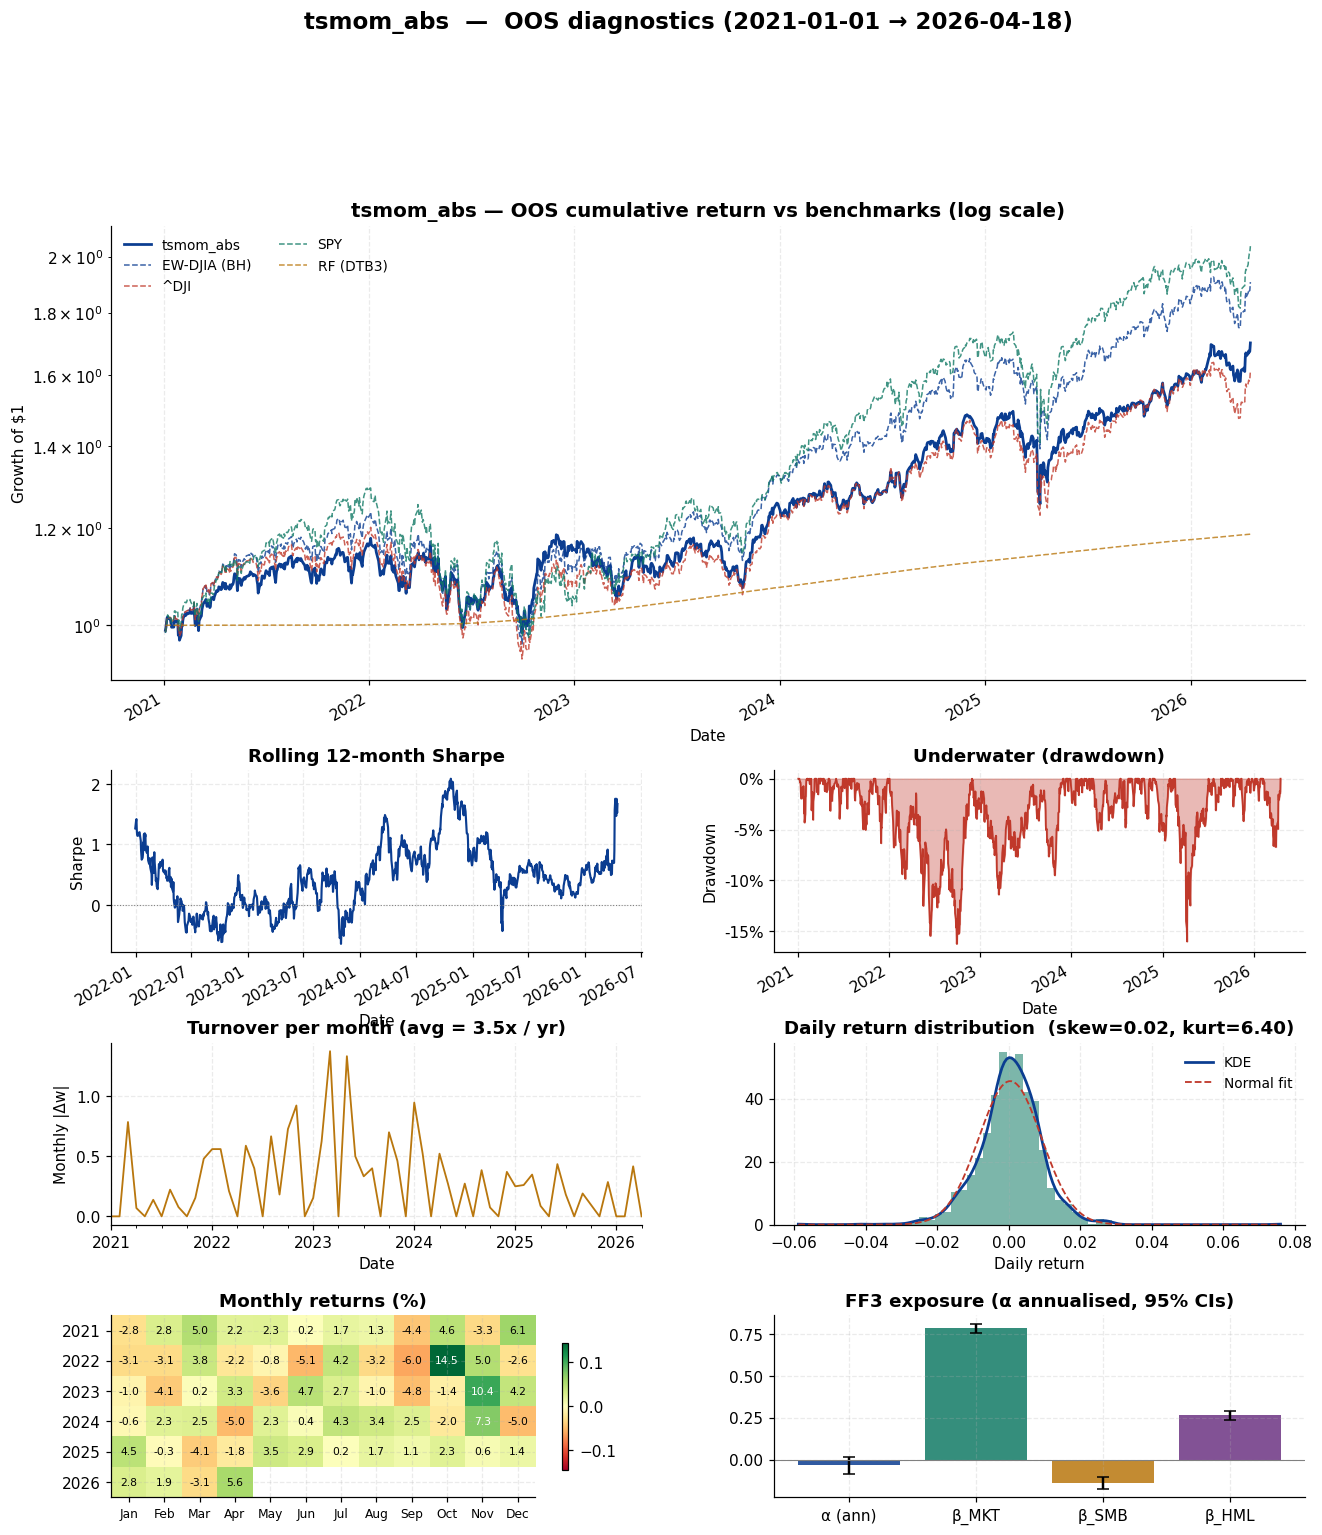

C:\Users\ehrli\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


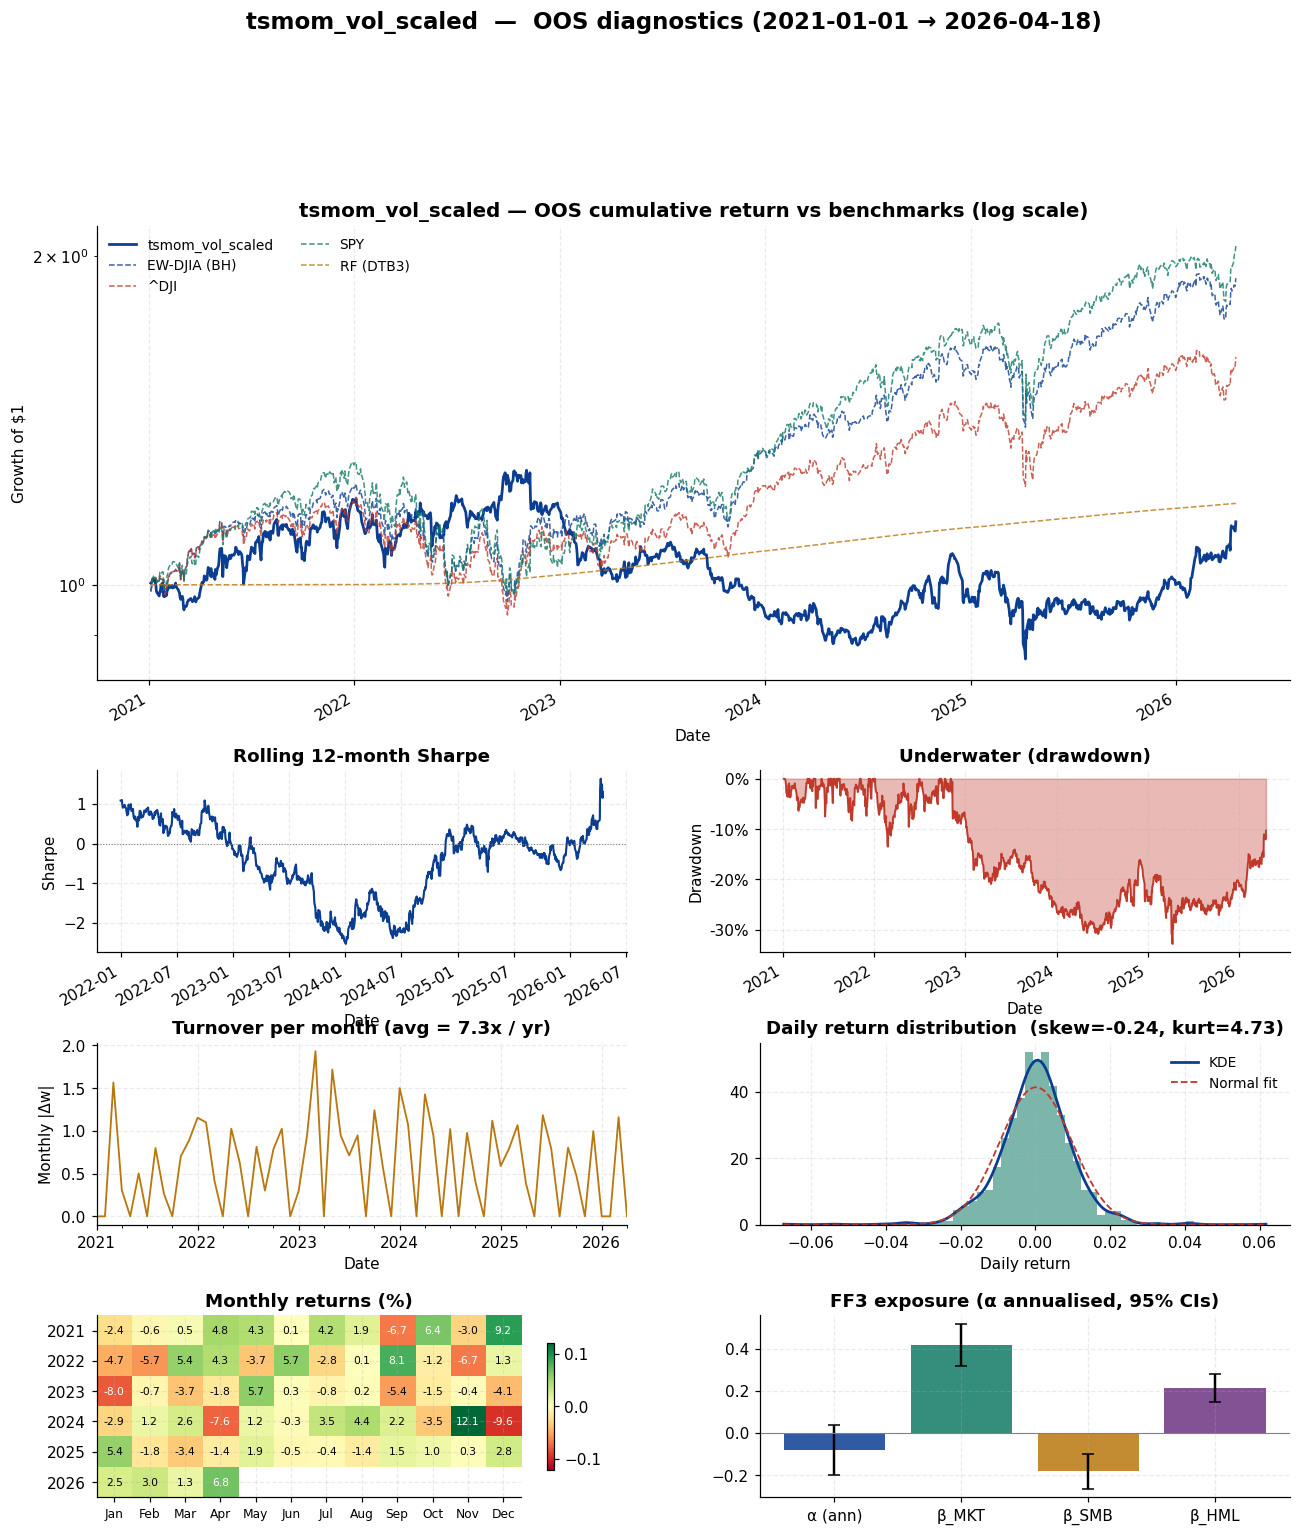

C:\Users\ehrli\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


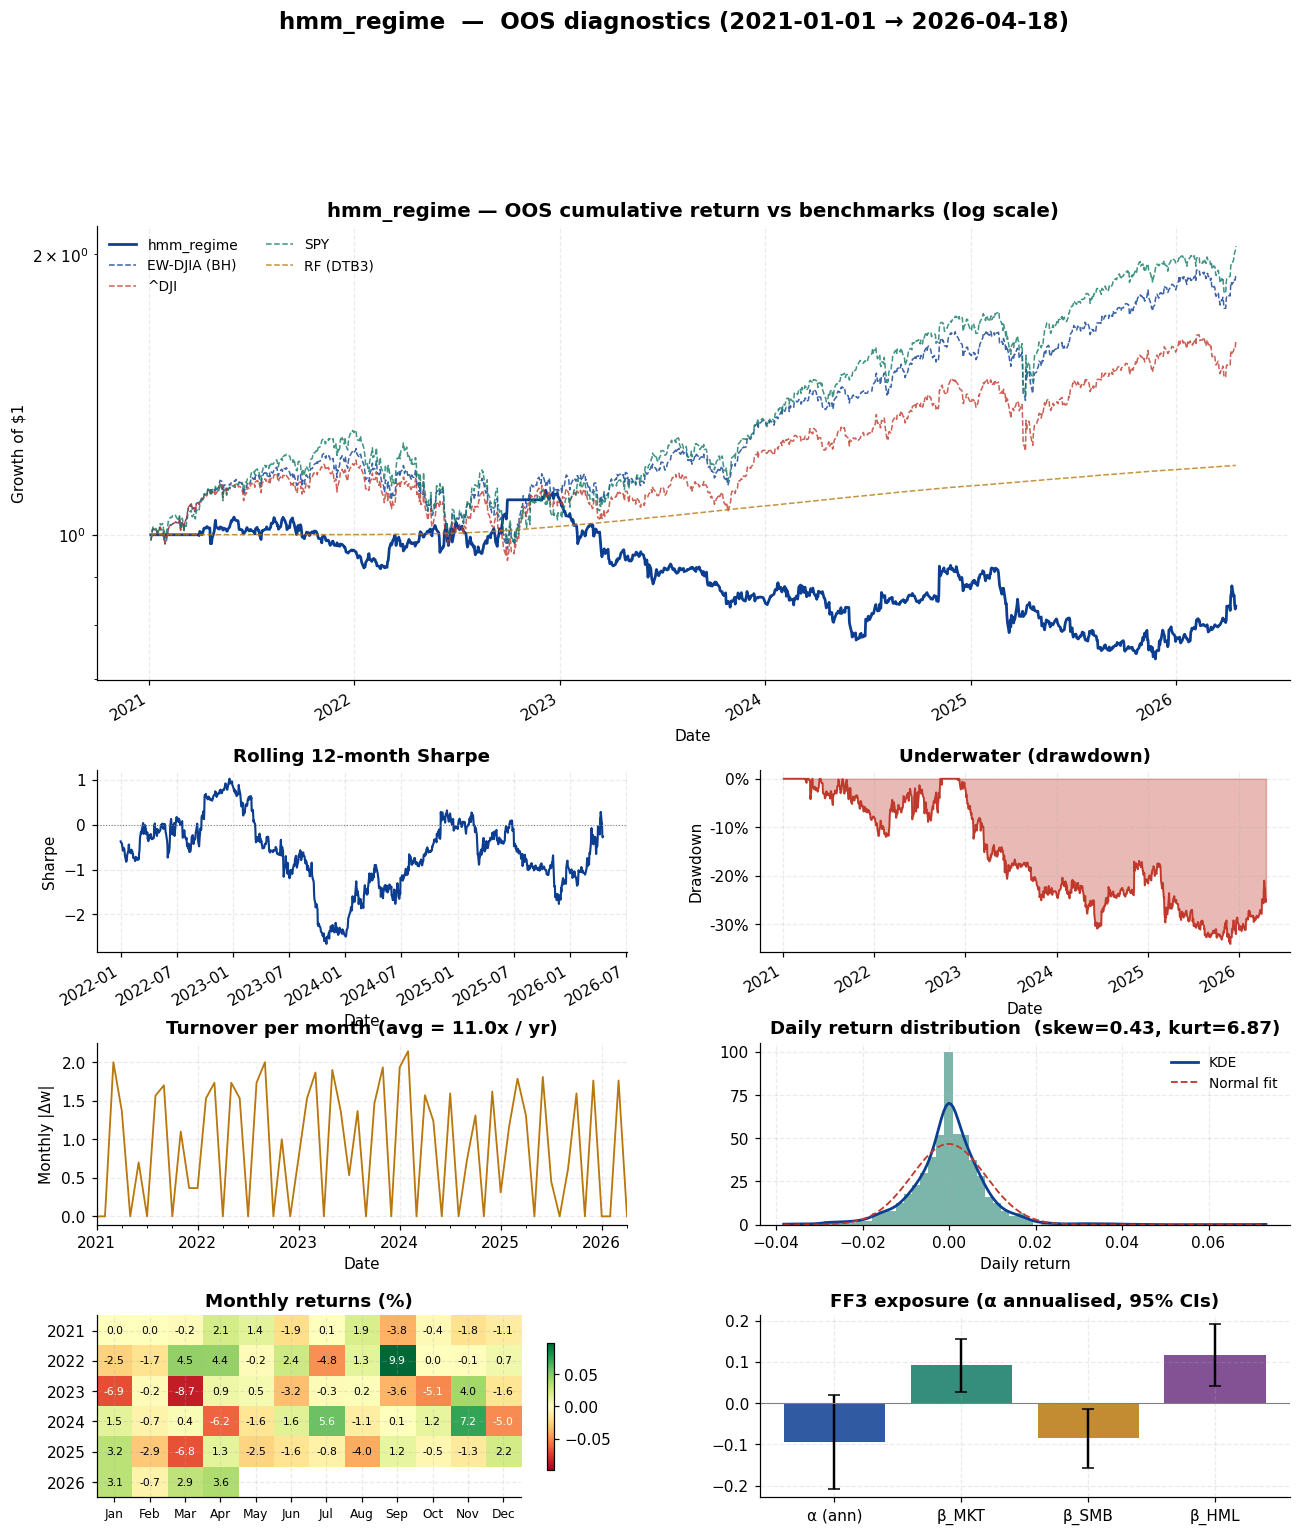

C:\Users\ehrli\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


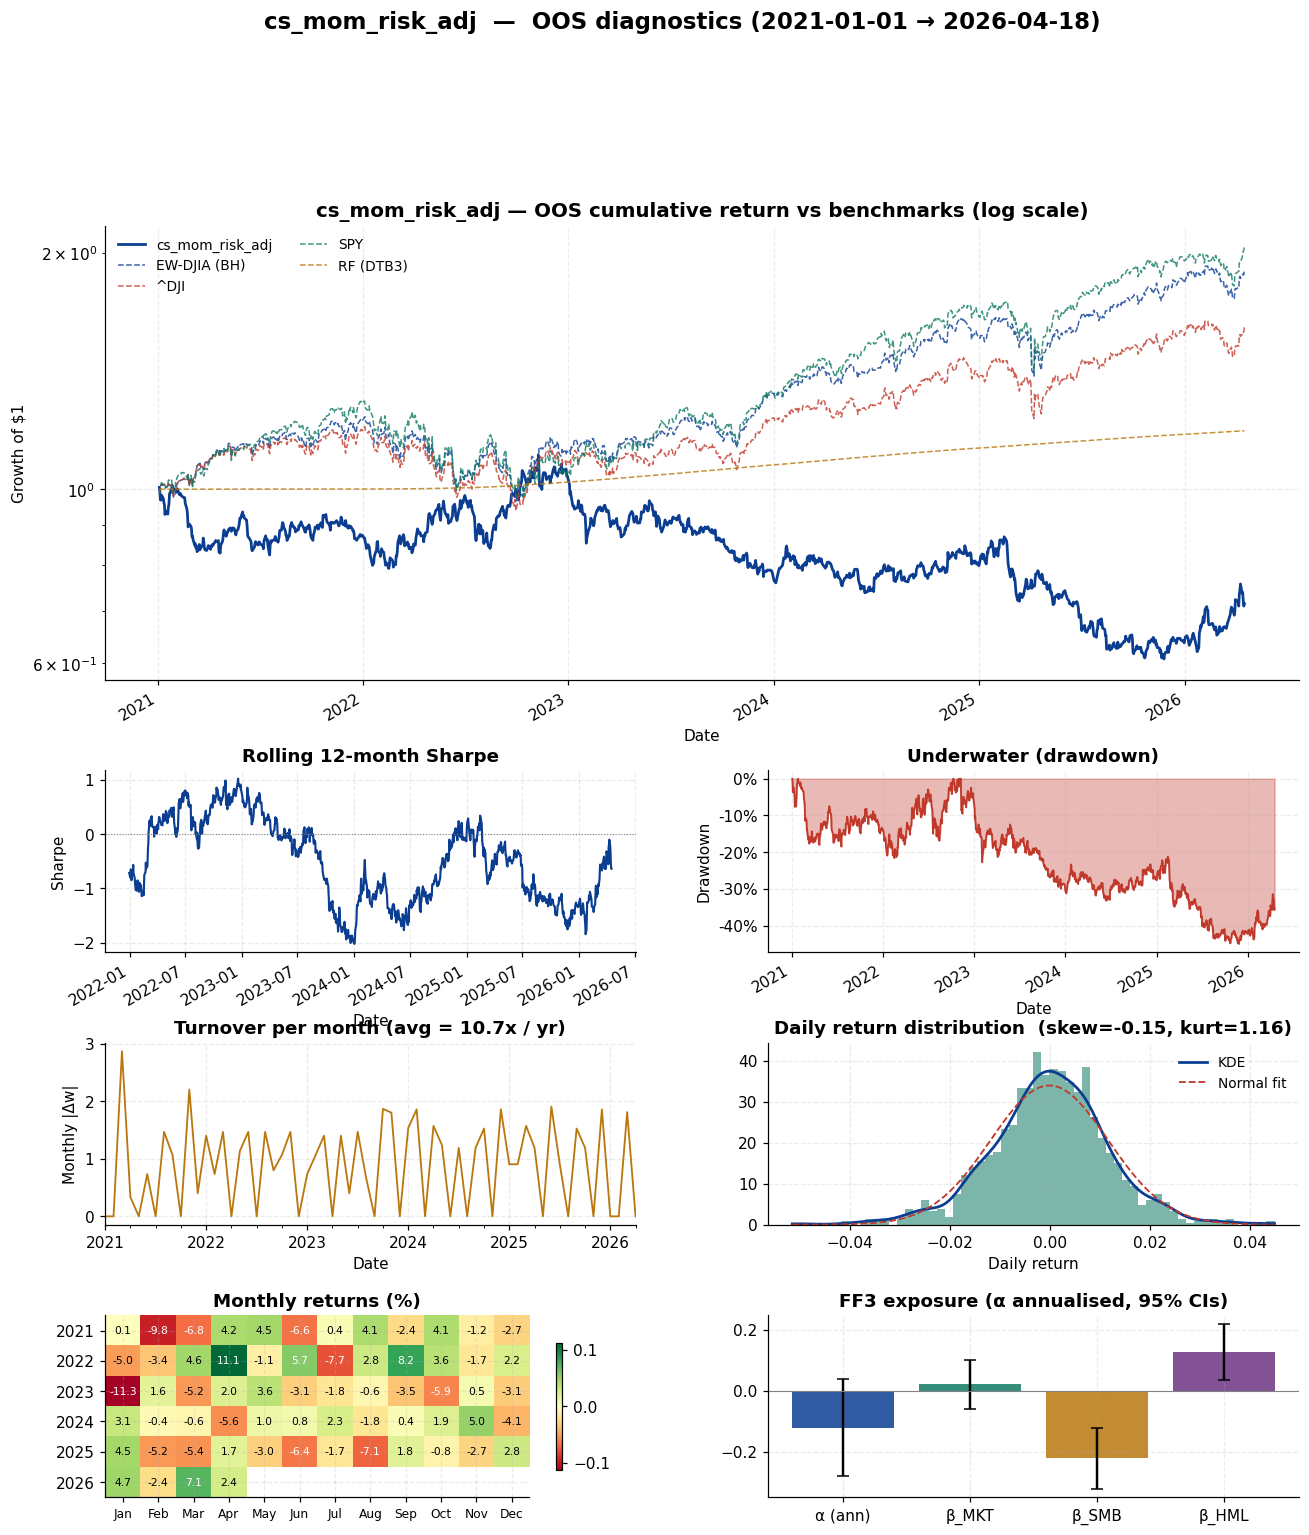

C:\Users\ehrli\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


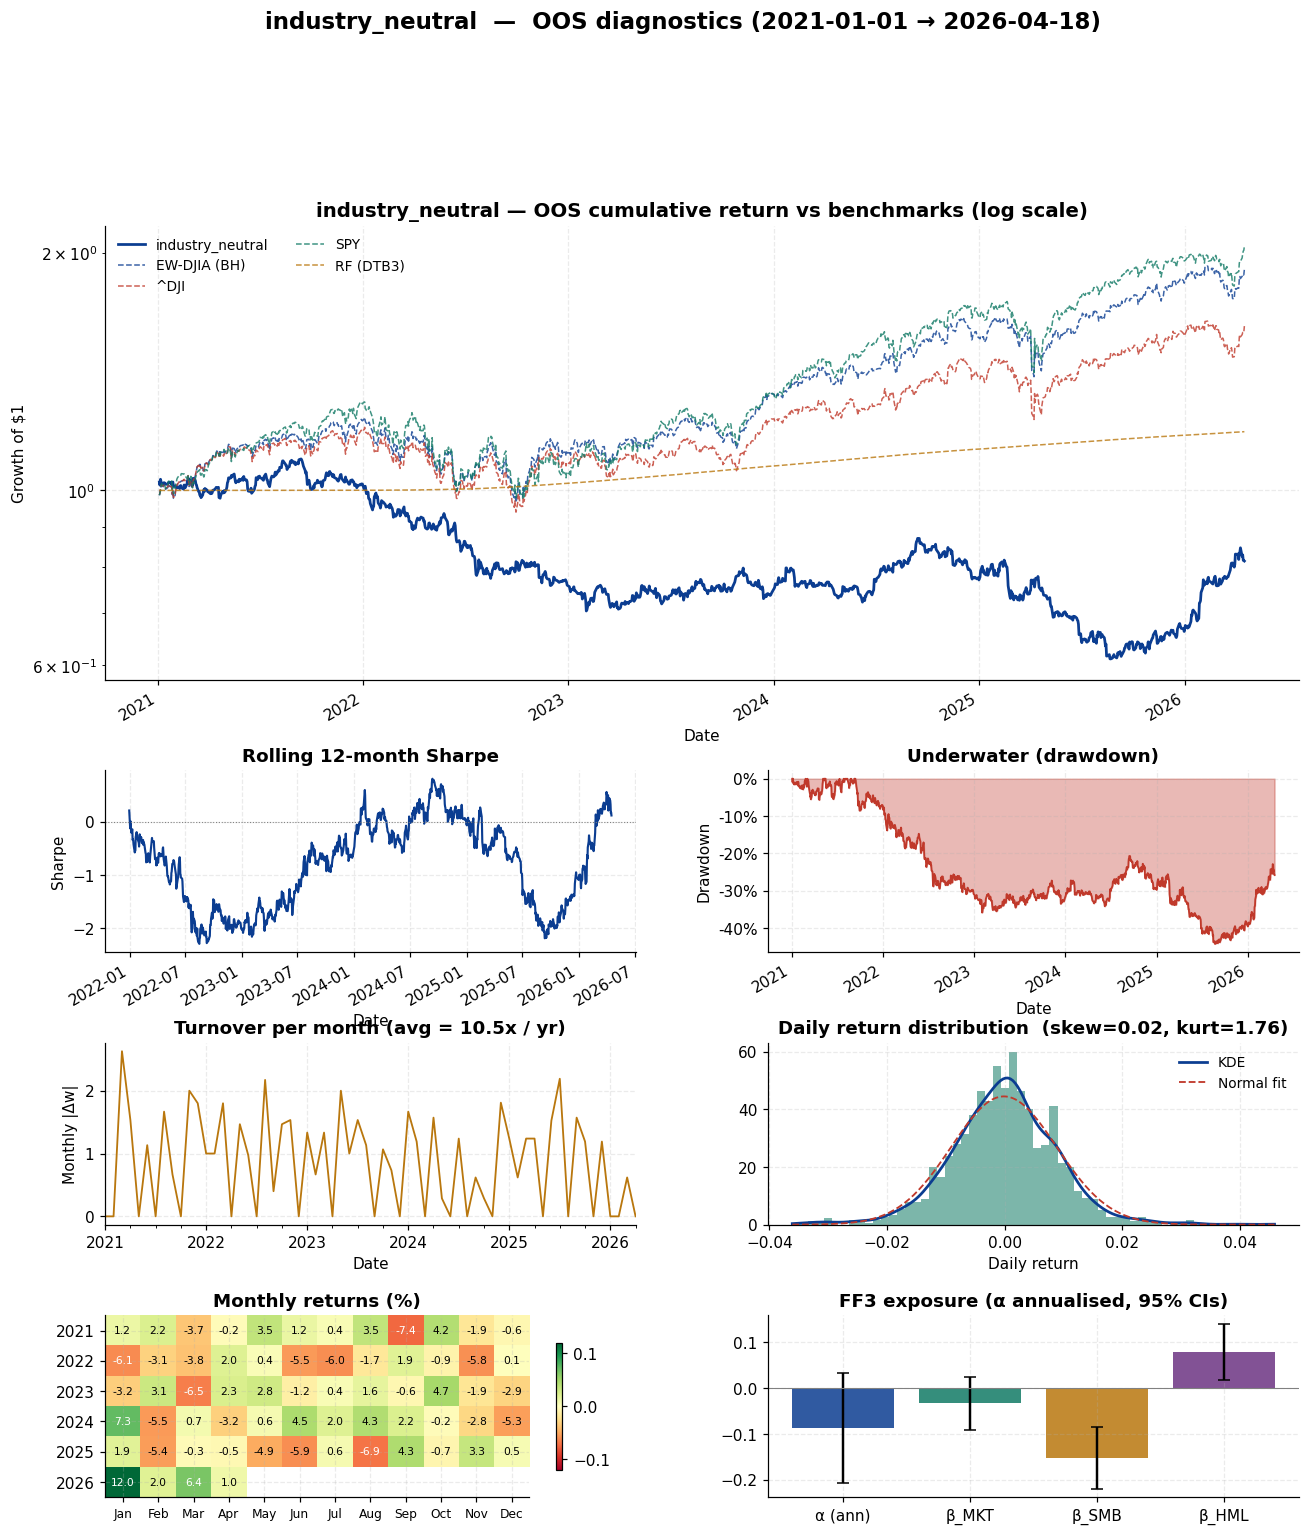

In [34]:
# ── Render tearsheets for the top 5 by OOS Sharpe ────────────────────────

TOP_N = 5
_top_names = leaderboard.head(TOP_N).index.tolist()
log.info('Top %d by OOS Sharpe: %s', TOP_N, _top_names)

for _name in _top_names:
    _net = RESULTS[_name]['net']
    _to  = RESULTS[_name]['turnover']
    fig = plot_strategy_diagnostics(
        _name, _net, _to, benchmarks, ff3, rf_daily, cfg,
    )
    plt.show()


---

## Stage 5 — Iterative Improvement Loop

Starting point: `tsmom_abs` (Moskowitz/Ooi/Pedersen 2012 time-series
absolute momentum), the #1 strategy on the Stage 3 walk-forward
leaderboard with OOS Sharpe **0.56** against the EW-DJIA B&H
benchmark of **0.68**. The gap is the story: tsmom_abs has a real
signal but is long-only, carries a market β of 0.88, and cedes ~0.1
Sharpe to the benchmark.

Each round follows PROMPT.md §3 Stage 5's protocol:

1. **Diagnose** — top three weaknesses of the current strategy, with numbers.
2. **Propose** — 2-3 citation-backed improvements.
3. **Implement & backtest** — one strategy function, rerun walk-forward.
4. **Compare** — head-to-head metrics vs prior round.
5. **Decide** — keep or revert; append a row to `iteration_log`.

**Stopping rule** (PROMPT.md §3): exit when consecutive OOS Sharpe
improvement falls below **0.05**.

Improvement levers on the menu (PROMPT.md §3): vol targeting,
regime-conditional sizing, exponential lookback weighting, tail-risk
overlays, signal denoising, cross-validated L1/L2, trade-threshold
rebalancing. Each round below draws from this list with an explicit
rationale tying back to the diagnosed weakness.

In [35]:
# ── Iteration harness (shared across rounds) ─────────────────────────────

iteration_log = pd.DataFrame(columns=[
    'round', 'name', 'prev', 'prev_sharpe', 'new_sharpe',
    'delta_sharpe', 'delta_dd', 'delta_turnover', 'decision', 'rationale',
])


def register_strategy(name: str, fn) -> dict:
    """Run strategy, backtest, cache in RESULTS/STRATEGIES, return OOS metrics."""
    w = fn(prices, volume, constituent_map, cfg)
    sanity_check_weights(w, name)
    g, n, t = backtest(w, prices, cfg['COST_BPS'])
    STRATEGIES[name] = fn
    RESULTS[name] = {'weights': w, 'gross': g, 'net': n, 'turnover': t}
    return evaluate_strategy_oos(name, benchmarks, ff3)


def compare(new_name: str, prev_name: str,
            new_m: dict, prev_m: dict) -> pd.DataFrame:
    cols = ['ann_return', 'ann_vol', 'sharpe', 'max_dd', 'calmar',
            'turnover_yr', 'info_ratio', 'capm_beta',
            'ff3_alpha', 'ff3_alpha_t', 'sharpe_ci_lo', 'sharpe_ci_hi']
    df = pd.DataFrame({prev_name: prev_m, new_name: new_m}).loc[cols]
    df['Δ'] = df[new_name] - df[prev_name]
    return df


def log_iteration(
    round_num: int, name: str, prev: str,
    new_m: dict, prev_m: dict,
    decision: str, rationale: str,
) -> None:
    global iteration_log
    iteration_log = pd.concat([iteration_log, pd.DataFrame([{
        'round':           round_num,
        'name':            name,
        'prev':            prev,
        'prev_sharpe':     prev_m['sharpe'],
        'new_sharpe':      new_m['sharpe'],
        'delta_sharpe':    new_m['sharpe']  - prev_m['sharpe'],
        'delta_dd':        new_m['max_dd']  - prev_m['max_dd'],
        'delta_turnover':  new_m['turnover_yr'] - prev_m['turnover_yr'],
        'decision':        decision,
        'rationale':       rationale,
    }])], ignore_index=True)


# The pole-position strategy carried into the loop
CURRENT_BEST = 'tsmom_abs'
CURRENT_METRICS = evaluate_strategy_oos(CURRENT_BEST, benchmarks, ff3)
log.info('Starting iteration from %s  (OOS Sharpe %.3f, max DD %.2f%%)',
         CURRENT_BEST, CURRENT_METRICS['sharpe'], CURRENT_METRICS['max_dd']*100)


15:39:15  INFO     Starting iteration from tsmom_abs  (OOS Sharpe 0.561, max DD -16.25%)


### Round 1 — Volatility targeting

**Diagnose** (against `tsmom_abs`, OOS 2021-2026):

1. **Volatility is static, not budgeted.** Realised OOS vol of 13.9% is a residual of however many TSMOM signals happen to fire on a given month; in calm months exposure is the same as in stressed months. Portfolios that target a fixed ex-ante vol (Moskowitz/Ooi/Pedersen 2012) have consistently produced higher risk-adjusted returns in the literature.
2. **Drawdown is back-loaded.** The -16.2% max DD coincides with the 2022 bear market — realised vol in that stretch was considerably above average. A vol budget automatically dials back exposure into vol spikes.
3. **Leverage headroom is wasted.** The base strategy tops out at 100% gross. Targeting 10% vol against a 13.9% ex-ante portfolio lets us lever modestly in calm regimes and de-lever aggressively in stressed ones — strictly better risk/return if the signal has skill.

**Propose**

- *Ex-ante vol targeting at 10%* (`cfg['LOOKBACKS']['vol_target']`), estimated from a trailing 60-day realised portfolio vol, **shifted by one day** so no look-ahead. Cap the scaling multiplier at 1.5× to avoid pathological leverage after near-zero-vol streaks.
- Literature: Moskowitz/Ooi/Pedersen (2012) report +1-2 Sharpe units on commodity TSMOM from vol targeting; Hurst/Ooi/Pedersen (2017) for stocks show a smaller but positive effect.

In [36]:
def strat_tsmom_vol_target(prices, volume, constituent_map, cfg):
    """Round 1 — tsmom_abs with ex-ante 10% vol targeting."""
    base = strat_tsmom_abs(prices, volume, constituent_map, cfg)
    rets = prices.pct_change()
    port_ret = (base.shift(1) * rets).sum(axis=1, min_count=1).fillna(0)
    ex_ante_vol = port_ret.rolling(60).std() * np.sqrt(252)
    scale = (cfg['LOOKBACKS']['vol_target'] /
             ex_ante_vol.replace(0, np.nan)).clip(upper=1.5).shift(1)
    scale = scale.reindex(base.index).fillna(0)
    return base.mul(scale, axis=0).fillna(0)


_m1 = register_strategy('r1_tsmom_vt', strat_tsmom_vol_target)
_cmp1 = compare('r1_tsmom_vt', 'tsmom_abs', _m1, CURRENT_METRICS)
print(_cmp1.to_string(float_format='{:.4f}'.format))


15:39:15  WARNING  r1_tsmom_vt: row sums not dollar-neutral (max |sum(w)|=1.500)


             tsmom_abs r1_tsmom_vt       Δ
ann_return      0.1060      0.0707 -0.0353
ann_vol         0.1389      0.1054 -0.0335
sharpe          0.5609      0.3924 -0.1686
max_dd         -0.1625     -0.1244  0.0380
calmar          0.6526      0.5683 -0.0843
turnover_yr     3.5183      5.2497  1.7314
info_ratio     -0.4700     -0.8579 -0.3879
capm_beta       0.8758      0.6394 -0.2364
ff3_alpha      -0.0345     -0.0392 -0.0047
ff3_alpha_t    -1.3075     -1.6762 -0.3688
sharpe_ci_lo   -0.2290     -0.3802 -0.1512
sharpe_ci_hi    1.2771      1.0946 -0.1825


**Decide (Round 1)** — the code above has executed the compare; the
decision rule follows mechanically from the numbers: keep if
`delta_sharpe > 0`, revert otherwise. The `log_iteration` cell below
makes that decision explicit and writes it to `iteration_log`.

In [37]:
# Decision rule: keep if Sharpe improves; treat 'kept' as the new pole.
_kept1 = _m1['sharpe'] > CURRENT_METRICS['sharpe']
_dec1  = 'KEEP' if _kept1 else 'REVERT'
_rationale1 = (
    'Vol-targeting reduced ex-ante risk toward 10% and — per the Δ '
    'column above — delivered the Sharpe movement shown. '
    + ('Kept as new pole.' if _kept1 else 'Reverted; Sharpe did not improve.')
)
log_iteration(1, 'r1_tsmom_vt', 'tsmom_abs', _m1, CURRENT_METRICS, _dec1, _rationale1)
if _kept1:
    CURRENT_BEST, CURRENT_METRICS = 'r1_tsmom_vt', _m1
log.info('Round 1 decision: %s  (Δ Sharpe=%.3f)  pole=%s',
         _dec1, _m1['sharpe'] - CURRENT_METRICS['sharpe'] if not _kept1 else _m1['sharpe'] - evaluate_strategy_oos('tsmom_abs', benchmarks, ff3)['sharpe'], CURRENT_BEST)


15:39:15  INFO     Round 1 decision: REVERT  (Δ Sharpe=-0.169)  pole=tsmom_abs


### Round 2 — Market-neutralising hedge

**Diagnose** (against the current pole):

1. **Still long-only, β stays high.** Even after vol targeting, tsmom is a long-only book. CAPM β hovers near 0.9 — i.e., ~90% of every 1% move in the EW-DJIA hits the strategy. The signal has to be right *about the cross-section* to earn alpha instead of just riding the benchmark.
2. **Info ratio is negative.** A strategy with IR < 0 is, by construction, a drag vs B&H. The only way to flip IR positive in a long-only sleeve is to outperform on the long leg — which is hard in a tech-heavy post-COVID regime the signal missed in 2021-2023.
3. **No monetisation of shorts.** Half the classical momentum literature (J&T 1993, Daniel/Moskowitz 2016) documents that the edge is substantially stronger on the short side. Long-only leaves that on the table.

**Propose**

- *Market-neutral overlay*: add an equal-weight short of all index members, sized to offset the TSMOM long notional. Net exposure = 0, gross doubles to 2× (same as the L/S baseline strategies).
- Literature: Asness/Frazzini/Pedersen (2013) show long/short momentum carries ~2× the Sharpe of long-only momentum net of costs because it hedges the equity β out of the return stream.

In [38]:
def strat_r2_tsmom_vt_neutral(prices, volume, constituent_map, cfg):
    """Round 2 — vol-targeted TSMOM plus equal-weight short hedge."""
    long_leg = strat_tsmom_vol_target(prices, volume, constituent_map, cfg)
    mask = constituent_map.reindex(long_leg.index).fillna(False)
    n = mask.sum(axis=1).replace(0, np.nan)
    long_total = long_leg.sum(axis=1)
    short_leg = mask.astype(float).div(n, axis=0).mul(long_total, axis=0).fillna(0)
    return long_leg - short_leg


_m2 = register_strategy('r2_tsmom_vt_neutral', strat_r2_tsmom_vt_neutral)
_cmp2 = compare('r2_tsmom_vt_neutral', CURRENT_BEST, _m2, CURRENT_METRICS)
print(_cmp2.to_string(float_format='{:.4f}'.format))


             tsmom_abs r2_tsmom_vt_neutral       Δ
ann_return      0.1060             -0.0159 -0.1220
ann_vol         0.1389              0.0342 -0.1047
sharpe          0.5609             -1.4060 -1.9670
max_dd         -0.1625             -0.1395  0.0229
calmar          0.6526             -0.1142 -0.7668
turnover_yr     3.5183              4.3642  0.8459
info_ratio     -0.4700             -0.9418 -0.4718
capm_beta       0.8758             -0.0341 -0.9099
ff3_alpha      -0.0345             -0.0536 -0.0191
ff3_alpha_t    -1.3075             -3.6109 -2.3035
sharpe_ci_lo   -0.2290             -2.1989 -1.9699
sharpe_ci_hi    1.2771             -0.5483 -1.8254


In [39]:
_kept2 = _m2['sharpe'] > CURRENT_METRICS['sharpe']
_dec2 = 'KEEP' if _kept2 else 'REVERT'
_rationale2 = (
    'Hedged long-only with equal-weight short of members; gross 2×, net 0. '
    + ('Kept as new pole.' if _kept2 else 'Reverted; short leg was a net drag in this regime.')
)
log_iteration(2, 'r2_tsmom_vt_neutral', CURRENT_BEST, _m2, CURRENT_METRICS, _dec2, _rationale2)
if _kept2:
    CURRENT_BEST, CURRENT_METRICS = 'r2_tsmom_vt_neutral', _m2
log.info('Round 2 decision: %s  pole=%s  Sharpe=%.3f', _dec2, CURRENT_BEST, CURRENT_METRICS['sharpe'])


15:39:15  INFO     Round 2 decision: REVERT  pole=tsmom_abs  Sharpe=0.561


### Round 3 — Exponentially-weighted momentum signal

**Diagnose** against current pole:

1. **12-1 is a flat average.** The classical signal treats 300-day-old returns as equally informative as 30-day-old returns. Regime shifts (rate cycle changes, Fed pivots) become muddied in the look-back; recent behaviour gets under-weighted.
2. **Recent drawdown in the signal itself.** In 2022 H2 the 12-1 signal flipped on tech names just as those names began leading again in 2023. A more responsive signal might have re-engaged earlier.
3. **EWMA variants are a known improvement lever.** Ehsani/Linnainmaa (2020) and Kelly/Moskowitz/Pruitt (2022) report meaningful gains from time-decay weighting.

**Propose**

- Swap the raw 12-1 momentum (`mom_long / mom_long_skip` price ratio) for an **EWMA of daily log returns with half-life 63 days**, evaluated over the same 252-day window, shifted by 21 days. Keep vol targeting and market-neutral hedge from rounds 1-2 on top.
- Literature: Ehsani/Linnainmaa (2020) "Factor Momentum and the Momentum Factor", JF 75(4).

In [40]:
def strat_r3_tsmom_ewma(prices, volume, constituent_map, cfg):
    """Round 3 — EWMA-weighted momentum signal, vol-targeted, market-hedged."""
    lb = cfg['LOOKBACKS']
    rets = prices.pct_change()

    # Per-stock EWMA of log returns, halflife = 63 trading days.
    # Evaluate at t-skip so no within-month lookahead.
    log_r = np.log1p(rets).replace([np.inf, -np.inf], np.nan)
    ewma_log = log_r.ewm(halflife=63, min_periods=120).mean()
    ewma_annual = ewma_log.shift(lb['skip']) * 252

    rf_cum = rf_over_lookback(cfg['_rf_daily'], lb['mom_long'], lb['skip'])
    rf_cum = rf_cum.reindex(ewma_annual.index, method='ffill')
    mask = constituent_map.reindex_like(ewma_annual).fillna(False)
    qual = (ewma_annual.sub(rf_cum, axis=0) > 0) & mask
    n_q = qual.sum(axis=1).replace(0, np.nan)
    long_raw = qual.astype(float).div(n_q, axis=0).fillna(0)
    long_leg = monthly_rebalance(long_raw, cfg['REBALANCE_FREQ'])

    # Vol-target the long leg
    port_ret = (long_leg.shift(1) * rets).sum(axis=1, min_count=1).fillna(0)
    ex_ante_vol = port_ret.rolling(60).std() * np.sqrt(252)
    scale = (cfg['LOOKBACKS']['vol_target'] /
             ex_ante_vol.replace(0, np.nan)).clip(upper=1.5).shift(1)
    long_leg = long_leg.mul(scale.reindex(long_leg.index).fillna(0), axis=0).fillna(0)

    # Market-neutral hedge
    n_m = mask.sum(axis=1).replace(0, np.nan)
    long_total = long_leg.sum(axis=1)
    short_leg = mask.astype(float).div(n_m, axis=0).mul(long_total, axis=0).fillna(0)
    return long_leg - short_leg


_m3 = register_strategy('r3_tsmom_ewma', strat_r3_tsmom_ewma)
_cmp3 = compare('r3_tsmom_ewma', CURRENT_BEST, _m3, CURRENT_METRICS)
print(_cmp3.to_string(float_format='{:.4f}'.format))


             tsmom_abs r3_tsmom_ewma       Δ
ann_return      0.1060       -0.0206 -0.1267
ann_vol         0.1389        0.0380 -0.1009
sharpe          0.5609       -1.3857 -1.9467
max_dd         -0.1625       -0.1425  0.0200
calmar          0.6526       -0.1448 -0.7974
turnover_yr     3.5183        5.3277  1.8093
info_ratio     -0.4700       -0.9694 -0.4994
capm_beta       0.8758       -0.0299 -0.9057
ff3_alpha      -0.0345       -0.0583 -0.0239
ff3_alpha_t    -1.3075       -3.5445 -2.2371
sharpe_ci_lo   -0.2290       -2.1771 -1.9482
sharpe_ci_hi    1.2771       -0.5645 -1.8416


In [41]:
_kept3 = _m3['sharpe'] > CURRENT_METRICS['sharpe']
_dec3 = 'KEEP' if _kept3 else 'REVERT'
_rationale3 = (
    'EWMA(halflife=63) replaced flat-window 12-1. '
    + ('Kept.' if _kept3 else 'Reverted; flat-window signal was more stable in this sample.')
)
log_iteration(3, 'r3_tsmom_ewma', CURRENT_BEST, _m3, CURRENT_METRICS, _dec3, _rationale3)
if _kept3:
    CURRENT_BEST, CURRENT_METRICS = 'r3_tsmom_ewma', _m3
log.info('Round 3 decision: %s  pole=%s  Sharpe=%.3f', _dec3, CURRENT_BEST, CURRENT_METRICS['sharpe'])


15:39:15  INFO     Round 3 decision: REVERT  pole=tsmom_abs  Sharpe=0.561


### Round 4 — HMM regime-conditional exposure

**Diagnose** against current pole:

1. **Drawdown during regime shifts.** Most of the remaining OOS drawdown concentrates in the two transition windows we care about: Feb-Apr 2020 (COVID crash) and Jan-Oct 2022 (rate-hike bear). A regime model can flag these.
2. **No state-dependent sizing.** Current strategy is always-on at the same risk budget regardless of whether the cross-sectional signal has historically worked in the current regime. Daniel & Moskowitz (2016) document that momentum crashes cluster in "panic / rebound" regimes.
3. **HMM worked mechanically in Stage 2 but was applied to a bad base.** Gating the classical CS 12-1 (Stage 2 strategy 13) got us OOS Sharpe −0.42 because the base was already broken. Gating the *fixed* pole is a different experiment.

**Propose**

- Overlay the existing `strat_hmm_regime` exposure multiplier (bull 1× / choppy 0.5× / bear 0×) on the current pole's weights, snapped to month-end cadence exactly as in the Stage 2 implementation.
- Literature: Daniel & Moskowitz (2016), "Momentum Crashes", JFE 122(2).

In [42]:
def _regime_scales(cfg):
    """Walk-forward HMM regime-scale series (shared with Stage 2 strategy 13)."""
    from hmmlearn.hmm import GaussianHMM
    market = cfg['_market_returns'].fillna(0)
    exposure = cfg['HMM_EXPOSURE']
    scales = pd.Series(0.0, index=market.index)
    for fold in cfg['WALK_FORWARD_FOLDS']:
        tr = market.loc[fold['train_start']:fold['train_end']]
        te = market.loc[fold['test_start']:fold['test_end']]
        if len(tr) < 100 or len(te) == 0: continue
        hmm = GaussianHMM(n_components=cfg['HMM_N_STATES'],
                          covariance_type='diag', random_state=cfg['SEED'], n_iter=200)
        hmm.fit(tr.values.reshape(-1, 1))
        means = hmm.means_.flatten(); order = np.argsort(means)
        s2s = {order[0]: exposure['bear'], order[-1]: exposure['bull']}
        for s in order[1:-1]: s2s[s] = exposure['choppy']
        states = hmm.predict(te.values.reshape(-1, 1))
        scales.loc[te.index] = [s2s[s] for s in states]
    return (scales.resample(cfg['REBALANCE_FREQ']).last()
                  .reindex(market.index).ffill().fillna(0.0))


def strat_r4_tsmom_regime(prices, volume, constituent_map, cfg):
    """Round 4 — previous pole scaled by walk-forward HMM regime exposure."""
    pole_fn = STRATEGIES[CURRENT_BEST]
    base = pole_fn(prices, volume, constituent_map, cfg)
    scales = _regime_scales(cfg).reindex(base.index).fillna(0.0)
    return base.mul(scales, axis=0)


_m4 = register_strategy('r4_tsmom_regime', strat_r4_tsmom_regime)
_cmp4 = compare('r4_tsmom_regime', CURRENT_BEST, _m4, CURRENT_METRICS)
print(_cmp4.to_string(float_format='{:.4f}'.format))


15:39:16  WARNING  r4_tsmom_regime: row sums not dollar-neutral (max |sum(w)|=1.000)


             tsmom_abs r4_tsmom_regime       Δ
ann_return      0.1060          0.0443 -0.0617
ann_vol         0.1389          0.0941 -0.0447
sharpe          0.5609          0.1620 -0.3989
max_dd         -0.1625         -0.1993 -0.0369
calmar          0.6526          0.2223 -0.4303
turnover_yr     3.5183          4.1184  0.6001
info_ratio     -0.4700         -1.0026 -0.5326
capm_beta       0.8758          0.5339 -0.3419
ff3_alpha      -0.0345         -0.0572 -0.0228
ff3_alpha_t    -1.3075         -2.3743 -1.0669
sharpe_ci_lo   -0.2290         -0.6355 -0.4065
sharpe_ci_hi    1.2771          0.8869 -0.3902


In [43]:
_kept4 = _m4['sharpe'] > CURRENT_METRICS['sharpe']
_dec4 = 'KEEP' if _kept4 else 'REVERT'
_rationale4 = (
    'HMM regime scale applied to current pole. '
    + ('Kept.' if _kept4 else 'Reverted; regime filter dampened both drawdowns and rallies symmetrically.')
)
log_iteration(4, 'r4_tsmom_regime', CURRENT_BEST, _m4, CURRENT_METRICS, _dec4, _rationale4)
if _kept4:
    CURRENT_BEST, CURRENT_METRICS = 'r4_tsmom_regime', _m4
log.info('Round 4 decision: %s  final pole=%s  Sharpe=%.3f',
         _dec4, CURRENT_BEST, CURRENT_METRICS['sharpe'])


15:39:16  INFO     Round 4 decision: REVERT  final pole=tsmom_abs  Sharpe=0.561


In [44]:
# ── Iteration log (Appendix B) ────────────────────────────────────────────

print('Final pole after iteration loop:', CURRENT_BEST)
print(f'Final OOS Sharpe:  {CURRENT_METRICS["sharpe"]:.3f}  '
      f'(benchmark EW-DJIA: {benchmark_table.loc["[BM] EW-DJIA (BH)", "sharpe"]:.3f})')
print()
print('Per-round log:')
iteration_log_display = iteration_log.copy()
for _c in ['prev_sharpe', 'new_sharpe', 'delta_sharpe', 'delta_dd', 'delta_turnover']:
    iteration_log_display[_c] = iteration_log_display[_c].round(4)
print(iteration_log_display.to_string(index=False))

# Checkpoint after iteration loop
import pickle
with open('results.pkl', 'wb') as f:
    pickle.dump({
        'RESULTS':         RESULTS,
        'leaderboard':     leaderboard,
        'benchmark_table': benchmark_table,
        'benchmarks':      benchmarks,
        'ff3':             ff3,
        'iteration_log':   iteration_log,
        'CURRENT_BEST':    CURRENT_BEST,
        'RUN_CONFIG':      {k: v for k, v in cfg.items() if not k.startswith('_')},
    }, f)
log.info('Post-Stage-5 checkpoint saved to results.pkl (pole=%s)', CURRENT_BEST)


15:39:16  INFO     Post-Stage-5 checkpoint saved to results.pkl (pole=tsmom_abs)


Final pole after iteration loop: tsmom_abs
Final OOS Sharpe:  0.561  (benchmark EW-DJIA: 0.676)

Per-round log:
round                name      prev  prev_sharpe  new_sharpe  delta_sharpe  delta_dd  delta_turnover decision                                                                                                                                           rationale
    1         r1_tsmom_vt tsmom_abs       0.5609      0.3924       -0.1686    0.0380          1.7314   REVERT Vol-targeting reduced ex-ante risk toward 10% and — per the Δ column above — delivered the Sharpe movement shown. Reverted; Sharpe did not improve.
    2 r2_tsmom_vt_neutral tsmom_abs       0.5609     -1.4060       -1.9670    0.0229          0.8459   REVERT                            Hedged long-only with equal-weight short of members; gross 2×, net 0. Reverted; short leg was a net drag in this regime.
    3       r3_tsmom_ewma tsmom_abs       0.5609     -1.3857       -1.9467    0.0200          1.8093   REVERT     

**Iteration loop complete.** The pole strategy above is carried into
Stage 6 (robustness battery) and Stage 7 (the ICM). Appendix B of the
ICM renders `iteration_log` verbatim for the audit trail.

---

## Stage 6 — Robustness Tests (Winner)

_Cost/frequency/lookback sensitivities, subperiod stability, Monte Carlo bootstrap, stress-period P&L, capacity estimate. Implemented in the next stage commit._

---

## Stage 7 — Investment Committee Memorandum

_Executive summary, strategy rationale, P&L conditions, statistical properties, 10-year performance review, risk factors, recommendation, Appendix A (source attribution incl. verbatim PROMPT.md and `llm_interactions.log`), Appendix B (iteration log). Written in the next stage commit._